## Execução

In [1]:
from datetime import datetime
from zoneinfo import ZoneInfo

RUN_AT = datetime.now(ZoneInfo("America/Sao_Paulo"))
print(f"Última execução: {RUN_AT.strftime('%d/%m/%Y %H:%M:%S %Z')}")

Última execução: 24/07/2026 11:08:15 -03


## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [4]:
from funcoes_monitoramento import *
from funcoes_psi import *

In [5]:
from funcoes_monitoramento import compute_category_mix, _draw_rating_mix_panel

## Diretório e Configurações

In [6]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

In [7]:
MODEL_ORDER = [
    "BLEND4",
    "BLEND3",
    "BLEND_REGRESSAO_2026",
    # "BVS_CUSTOM",
    # "HVA3",
    # "HVA4",
]

MODEL_ORDER_GRAPH = ["BLEND4", "BLEND3"]

MODEL_COL = "bureau_nm_ajust"
RATING_COL = "rating_score_ds"

MODEL_COLOR_MAP = {
    "BLEND4": "#3B82F6",
    "BLEND3": "#94A3B8",
    "BLEND_REGRESSAO_2026": "#8B5CF6",
    # "BVS_CUSTOM": "#06B6D4",
    # "HVA3": "#14B8A6",
    # "HVA4": "#6366F1",
}

RATING_ORDER = ["A", "B", "C", "D", "E", "N/I"]
RATING_COLOR_MAP = {
    "A": "#7DD3FC",
    "B": "#5EEAD4",
    "C": "#93C5FD",
    "D": "#818CF8",
    "E": "#334155",
    "N/I": "#CBD5E1",
}
RATING_TEXT_COLOR_MAP = {
    "A": "white", "B": "white", "C": "black",
    "D": "white", "E": "white", "N/I": "black",
}

PRE_ANALISE_ORDER = ["APROVAR", "DERIVAR", "REPROVAR"]
PRE_ANALISE_COLOR_MAP = {
    "APROVAR": "#9ECACA",
    "DERIVAR": "#B5BFE8",
    "REPROVAR": "#9AA5B1",
}
PRE_ANALISE_TEXT_COLOR_MAP = {
    "APROVAR": "white", "DERIVAR": "white", "REPROVAR": "white",
}

FUNNEL_BINARY_STEPS = [
    "is_elegivel",
    "is_iniciada",
    "is_enviada",
    "is_aprovada",
    "is_ativada",
]

BLEND_FUNNEL_METRICS = [
    "elegivel_pct_total",
    "iniciada_pct_elegivel",
    "enviada_pct_iniciada",
    "aprovada_pct_enviada",
    "ativada_pct_aprovada",
    "conversao_pct_total",
]

In [8]:
RATING_GROUP_ORDER = {
    "A+": "A",
    "A": "A",
    "B+": "A",
    "B": "A",
    "C": "B",
    "D+": "C",
    "D": "D",
    "E": "E",
    "E-BVS": "E",
}

RATING_DS_POL_ORDER = {
    "A+":"1.A+",
    "A":"2.A",
    "B+":"3.B+",
    "B":"4.B",
    "C":"5.C",
    "D+":"6.D+",
    "D":"7.D",
    "E":"8.E",
    "E-BVS":"9.E-BVS",
}

RATING_DS_POL_COLOR_MAP = {
    "1.A+":   "#22D3EE",  # best
    "2.A":    "#38BDF8",
    "3.B+":   "#2DD4BF",
    "4.B":    "#6EE7B7",
    "5.C":    "#93C5FD",
    "6.D+":   "#A5B4FC",
    "7.D":    "#818CF8",
    "8.E":    "#475569",
    "9.E-BVS": "#1E293B",
}

RATING_DS_POL_TEXT_COLOR_MAP = {
    "1.A+":    "black",
    "2.A":     "black",
    "3.B+":    "black",
    "4.B":     "black",
    "5.C":     "black",
    "6.D+":    "white",
    "7.D":     "white",
    "8.E":     "white",
    "9.E-BVS": "white",
}

In [9]:
MODEL_ORDER_FALLBACK = [
    "BLEND_4",
    "BLEND3_3",
    "BLEND_REGRESSAO_2026",
    "Fallback",
]

MODEL_COLOR_MAP_FALLBACK = {
    "BLEND_4": "#3B82F6",              # blue (mesmo espírito do BLEND4)
    "BLEND3_3": "#94A3B8",             # slate (mesmo espírito do BLEND3)
    "BLEND_REGRESSAO_2026": "#8B5CF6", # purple
    "Fallback": "#F59E0B",             # amber — destaque do grupo fallback
}

In [10]:
WINDOW_DAYS = 8
WINDOW_WEEKS = 6

## Base: Blend4 em Produção

In [11]:
df_raw = pd.read_csv(ANALYTICS_DIR / "df_funil_blend4.csv", low_memory=False)
df_raw["requested_at"] = pd.to_datetime(df_raw["requested_at"])

mask = df_raw["bureau_nm_ajust"] == "BLEND4"

df_raw["rating_score_group"] = df_raw["rating_score_ds"]
df_raw.loc[mask, "rating_score_group"] = (
    df_raw.loc[mask, "rating_score_ds"].replace(RATING_GROUP_ORDER)
)

df_raw["rating_score_ds"] = df_raw["rating_score_ds"]

df_raw.loc[mask, "rating_score_ds"] = (
    df_raw.loc[mask, "rating_score_ds"].replace(RATING_DS_POL_ORDER)
)

df_raw["modeloBlend_group"] = np.where(
    df_raw["is_fallback"] == 1,
    "Fallback",
    df_raw["modeloBlend"],
)

# mask_blend3_e = (
#     (df_raw["bureau_nm_ajust"] == "BLEND3")
#     & (df_raw["rating_score_ds"] == "8.E")
# )
# df_raw.loc[mask_blend3_e, "pre_analysis_result"] = "REPROVAR"

for col in ["iniciada_at", "enviada_at", "activated_at", "cancelled_at"]:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col], errors="coerce")

# Flags padronizadas do funil blend
df = prepare_blend_funnel_columns(df_raw)
df = prepare_week_columns(df, "requested_at")

# Produção real: evita duplicar contrato entre BLEND4 (simulado) e BLEND3_3 (prod)
# df_prod = df[df[MODEL_COL] == df["bureau_nm_ajust"]].copy()

print(f"Volume total (simulação): {len(df):,}")
print(f"Contratos únicos: {df['contract_id'].nunique():,}")
# print(f"Volume produção: {len(df_prod):,}")
print(f"Período: {df['requested_at'].min()} → {df['requested_at'].max()}")
# df.head()

Volume total (simulação): 95,927
Contratos únicos: 95,927
Período: 2026-07-01 00:00:00 → 2026-07-23 00:00:00


In [12]:
df_uniprop = df[df["qtd_proponentes"] == 1].copy()

df_multprop = df[df["qtd_proponentes"] >= 2].copy()

## Diário e Semanal

In [13]:
df_daily = filter_monitoring_window(
    df_uniprop,
    n_days=WINDOW_DAYS,
    mode="rolling",
)
# df_daily_prod = filter_monitoring_window(
#     df_prod,
#     n_days=WINDOW_DAYS,
#     mode="rolling",
# )

print(f"Diário simulação: {df_daily['requested_at'].min()} → {df_daily['requested_at'].max()} | n={len(df_daily):,}")
# print(f"Diário produção: {df_daily_prod['requested_at'].min()} → {df_daily_prod['requested_at'].max()} | n={len(df_daily_prod):,}")

Diário simulação: 2026-07-16 00:00:00 → 2026-07-23 00:00:00 | n=33,244


In [14]:
df_weekly = filter_monitoring_week_window(
    df_uniprop,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)
# df_weekly_prod = filter_monitoring_week_window(
#     df_prod,
#     n_weeks=WINDOW_WEEKS,
#     mode="rolling",
# )

print(f"Semanal simulação: {df_weekly['requested_at'].min()} → {df_weekly['requested_at'].max()} | n={len(df_weekly):,}")
# print(f"Semanal produção: {df_weekly_prod['requested_at'].min()} → {df_weekly_prod['requested_at'].max()} | n={len(df_weekly_prod):,}")

Semanal simulação: 2026-07-01 00:00:00 → 2026-07-23 00:00:00 | n=92,223


## Multiproponente vs. Uniproponente
Proporção de Multipronentes vs. Uniproponentes ao longo das semanas. O esperado é algo entre 3-4%.

In [15]:
PROPONENTE_ORDER = ["Uniproponente", "Multiproponente"]

PROPONENTE_COLOR_MAP = {
    "Uniproponente": "#94A3B8",   # slate
    "Multiproponente": "#3B82F6", # blue
}

PROPONENTE_TEXT_COLOR_MAP = {
    "Uniproponente": "white",
    "Multiproponente": "white",
}

def add_tipo_proponente(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["tipo_proponente"] = np.where(
        out["qtd_proponentes"] == 1,
        "Uniproponente",
        "Multiproponente",
    )
    return out

# Use df (BLEND4 + income > 0) ou df_raw (base completa)
df_prop = add_tipo_proponente(df_raw)

# print(df_prop["tipo_proponente"].value_counts(normalize=True).mul(100).round(2))
# print(df_prop["tipo_proponente"].value_counts())

In [16]:
WINDOW_DAYS = 8
WINDOW_WEEKS = 6

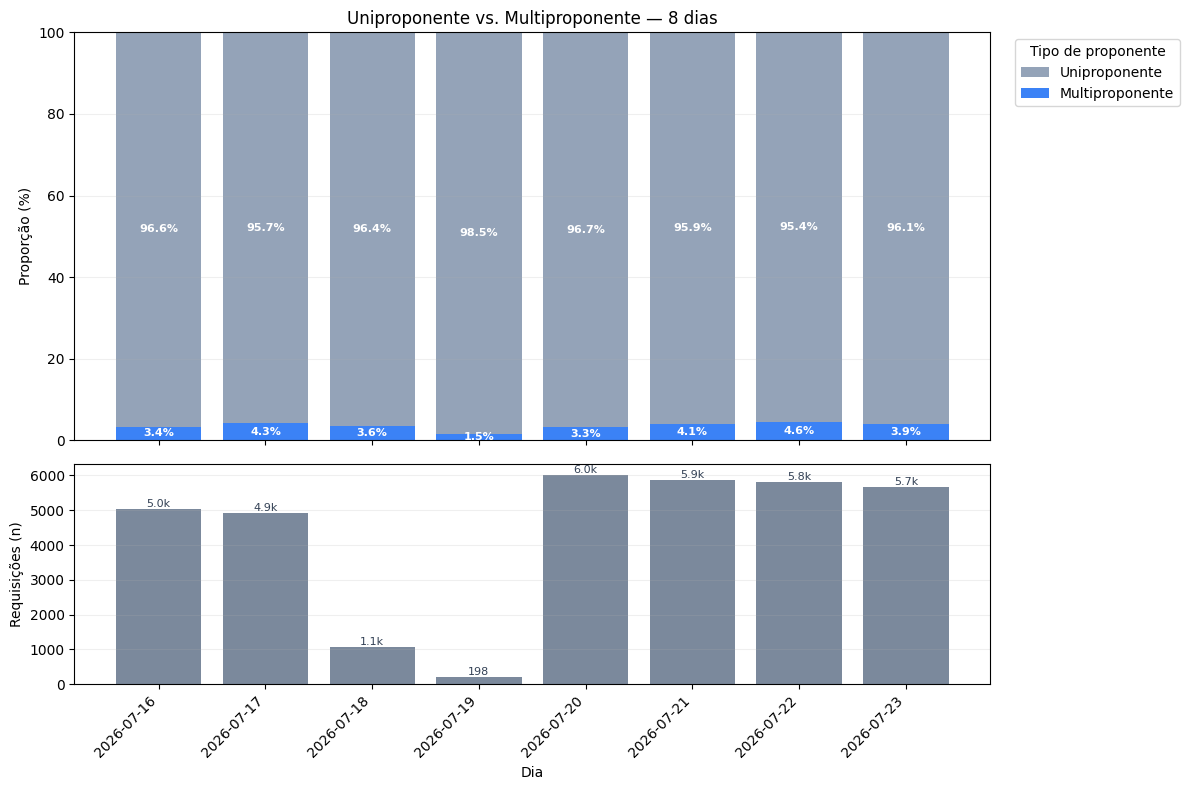

In [17]:
df_daily_prop = filter_monitoring_window(
    df_prop,
    n_days=WINDOW_DAYS,
    mode="rolling",
)

plot_daily_mix(
    df_daily_prop,
    category_col="tipo_proponente",
    title=f"Uniproponente vs. Multiproponente — {WINDOW_DAYS} dias",
    category_order=PROPONENTE_ORDER,
    color_map=PROPONENTE_COLOR_MAP,
    text_color_map=PROPONENTE_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Tipo de proponente",
    min_label_pct=1.0,
)

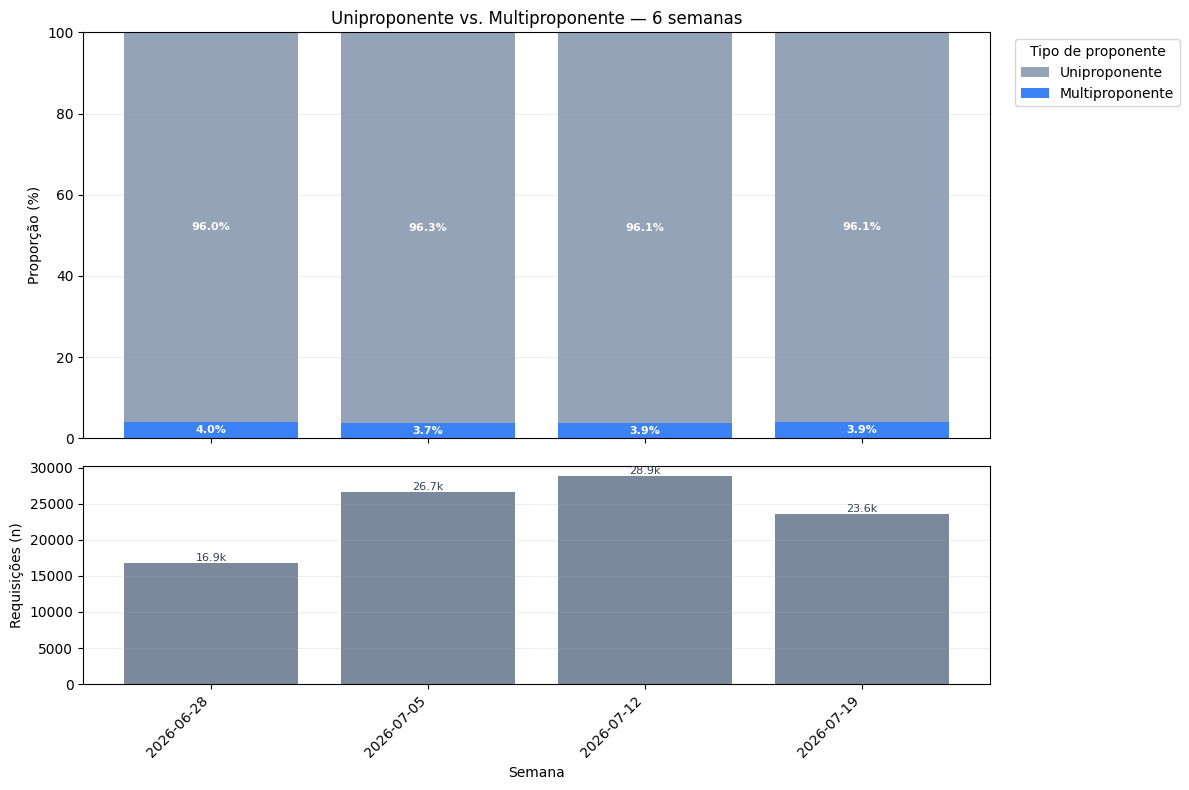

In [18]:
df_weekly_prop = filter_monitoring_week_window(
    df_prop,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)

plot_weekly_mix(
    df_weekly_prop,
    category_col="tipo_proponente",
    title=f"Uniproponente vs. Multiproponente — {WINDOW_WEEKS} semanas",
    category_order=PROPONENTE_ORDER,
    color_map=PROPONENTE_COLOR_MAP,
    text_color_map=PROPONENTE_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Tipo de proponente",
    min_label_pct=1.0,
)

# Uniproponentes

A partir daqui, seguimos apenas com o público Uniproponente.

## Mix de Modelos Diário e Semanal

Mix de Modelos dividido entre Blend3, Blend4 e Fallback. Blend2 foi descontinuado e deu lugar ao Blend4.

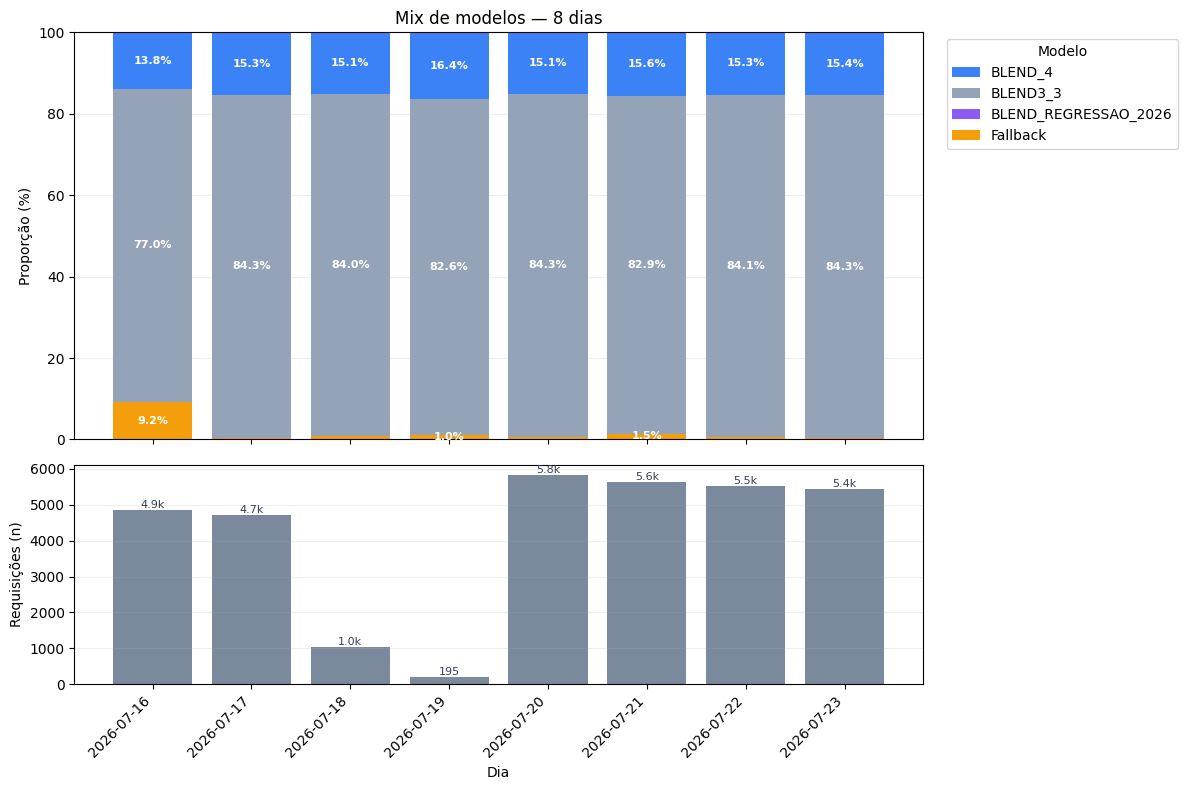

In [19]:
plot_daily_mix(
    df_daily,
    category_col="modeloBlend_group",
    title=f"Mix de modelos — {WINDOW_DAYS} dias",
    category_order=MODEL_ORDER_FALLBACK,
    color_map=MODEL_COLOR_MAP_FALLBACK,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=1.0,
)

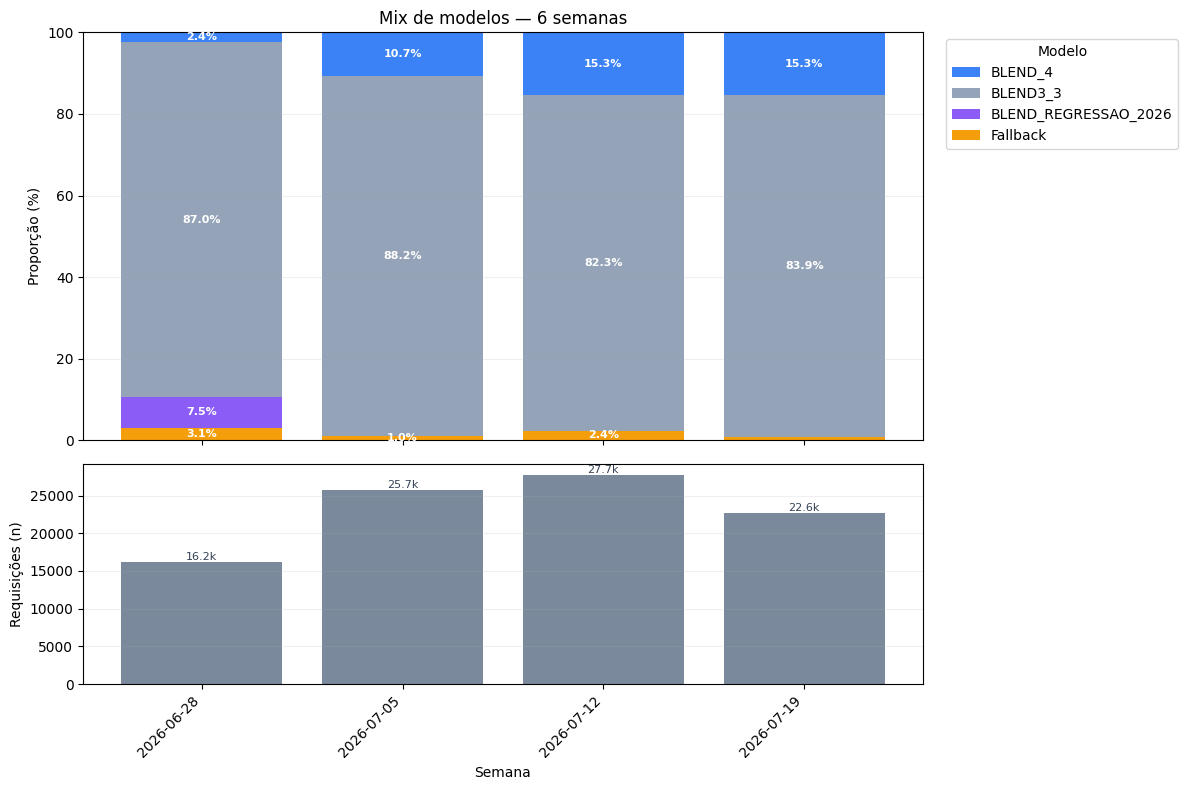

In [20]:
plot_weekly_mix(
    df_weekly,
    category_col="modeloBlend_group",
    title=f"Mix de modelos — {WINDOW_WEEKS} semanas",
    category_order=MODEL_ORDER_FALLBACK,
    color_map=MODEL_COLOR_MAP_FALLBACK,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=1.0,
)

## Mix de Modelos Diário e Semanal

Nesta etapa, retiramos o público que é FALLBACK e seguimos apenas com as comparações entre os Blend's que estão em produção (Blend 3 Blend4).

In [21]:
df_daily = df_daily[df_daily["modeloBlend_group"] != "Fallback"]
df_weekly = df_weekly[df_weekly["modeloBlend_group"] != "Fallback"]

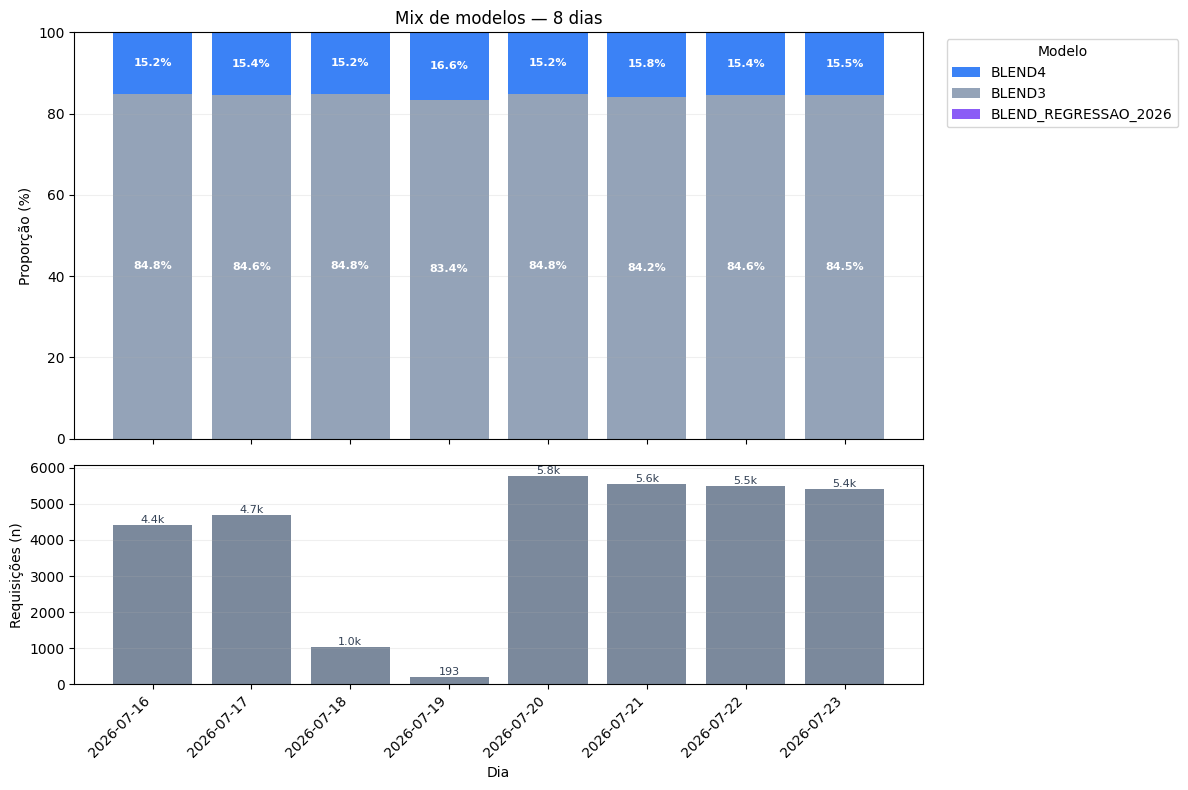

In [22]:
plot_daily_mix(
    df_daily,
    category_col=MODEL_COL,
    title=f"Mix de modelos — {WINDOW_DAYS} dias",
    category_order=MODEL_ORDER,
    color_map=MODEL_COLOR_MAP,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=3.0,
)

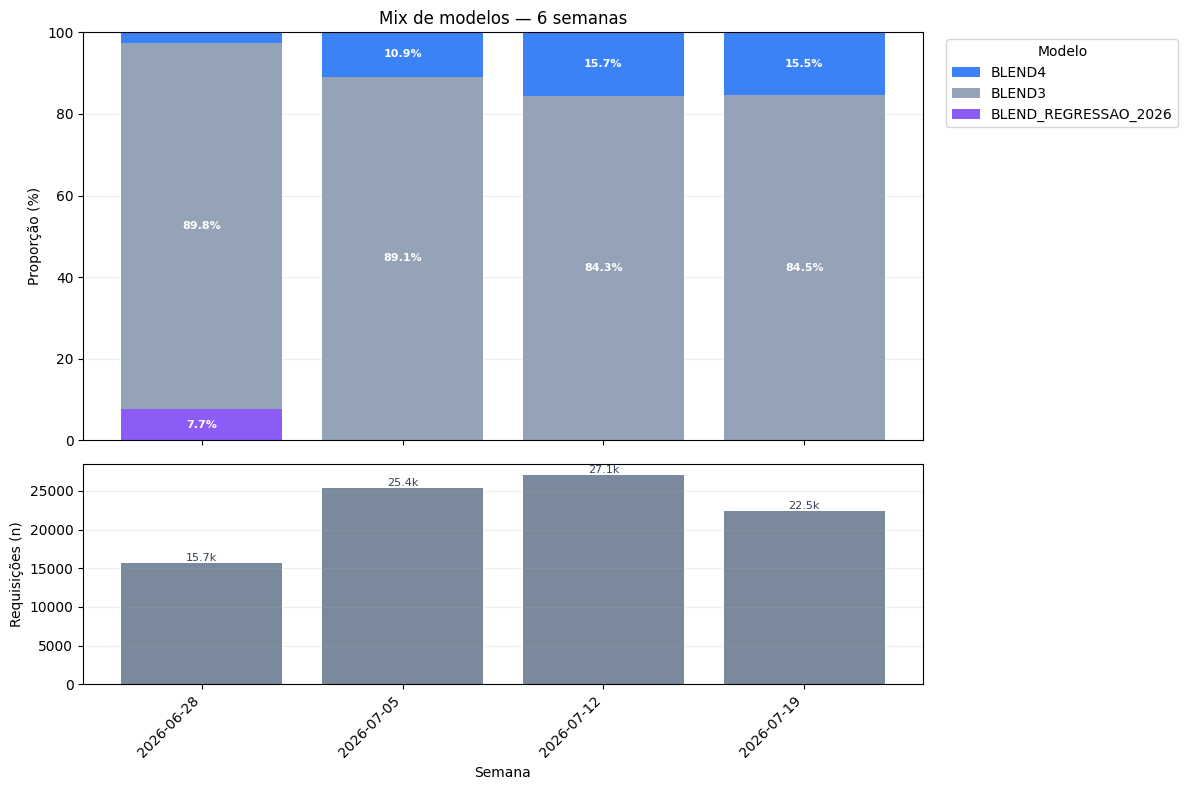

In [23]:
plot_weekly_mix(
    df_weekly,
    category_col=MODEL_COL,
    title=f"Mix de modelos — {WINDOW_WEEKS} semanas",
    category_order=MODEL_ORDER,
    color_map=MODEL_COLOR_MAP,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=3.0,
)

## Pré-Análise

Comparação do percentual de Aprovados, Derivados e Reprovados do Blend3 e Blend4.

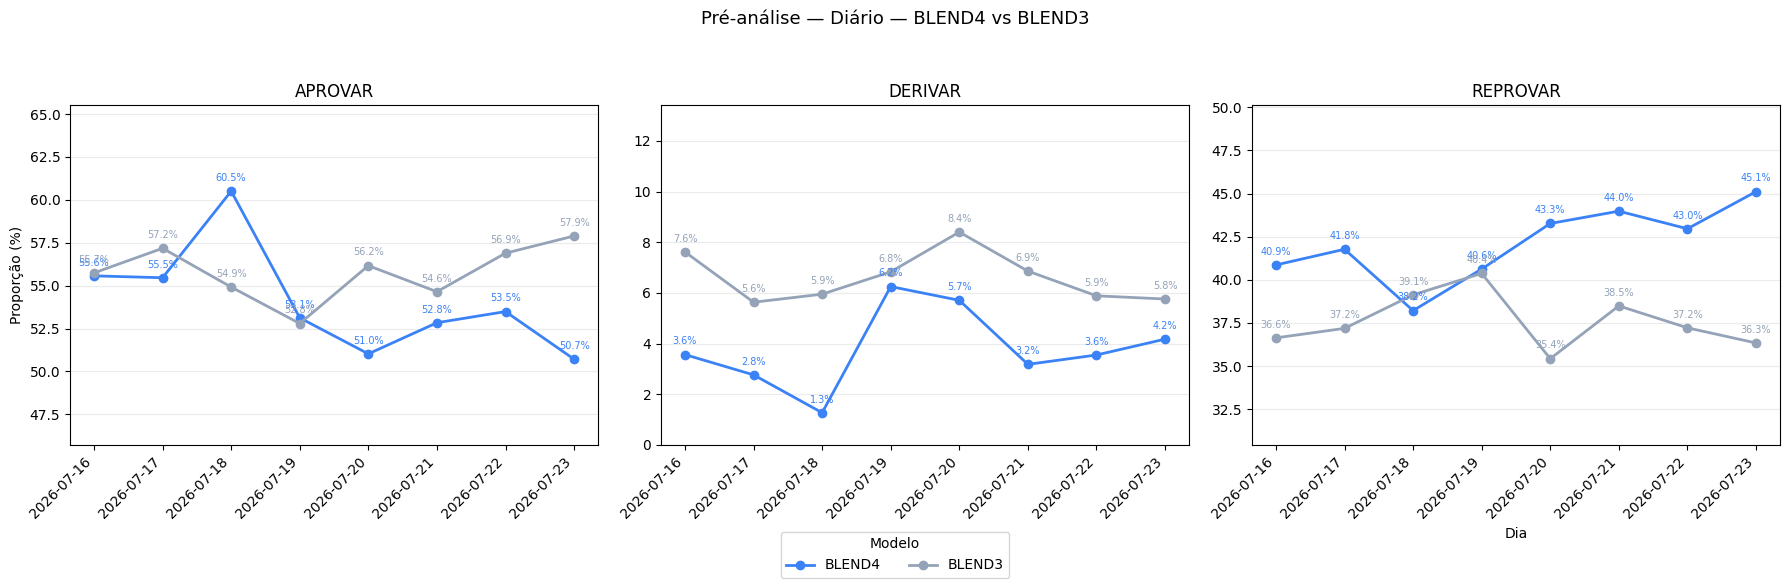

In [24]:
plot_pre_analysis_comparison(
    df_daily,
    models=MODEL_ORDER_GRAPH,
    time_grain="day",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Pré-análise — Diário — BLEND4 vs BLEND3",
    # ylim=(0, 100),
)

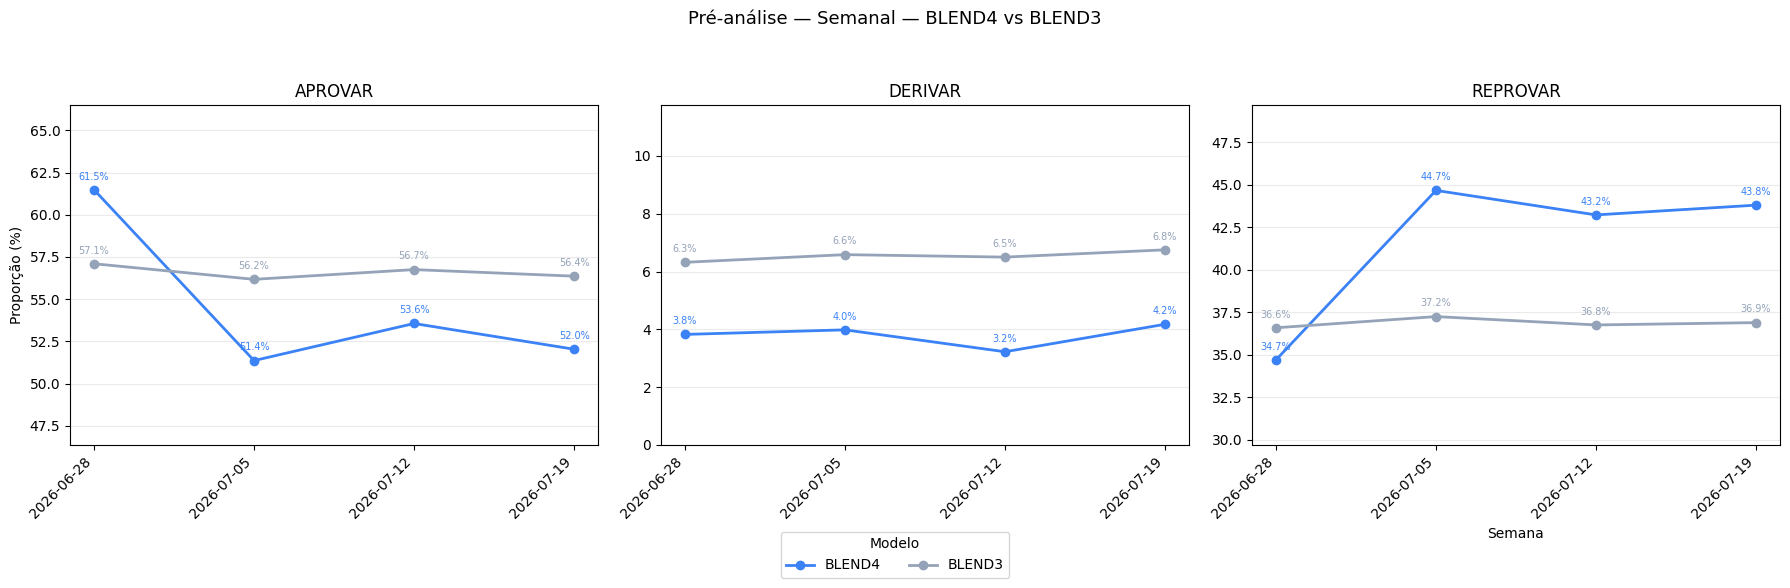

In [25]:
plot_pre_analysis_comparison(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    time_grain="week",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Pré-análise — Semanal — BLEND4 vs BLEND3",
    # ylim=(0, 100),
)

## Pré-Análise sem o Público Rating E do Blend3
Nesse caso, tiramos a elegibilidade do público que é Rating E do Blend 3.

In [26]:
df_daily_wt_E = df_daily.copy()
df_weekly_wt_E = df_weekly.copy()

dmask_blend3_e = (
    (df_daily_wt_E["bureau_nm_ajust"] == "BLEND3")
    & (df_daily_wt_E["rating_score_ds"] == "E")
)

wmask_blend3_e = (
    (df_weekly_wt_E["bureau_nm_ajust"] == "BLEND3")
    & (df_weekly_wt_E["rating_score_ds"] == "E")
)

df_daily_wt_E.loc[dmask_blend3_e, "pre_analysis_result"] = "REPROVAR"
df_weekly_wt_E.loc[wmask_blend3_e, "pre_analysis_result"] = "REPROVAR"

funnel_cols = ["is_elegivel", "is_iniciada", "is_enviada", "is_aprovada", "is_ativada"]
df_daily_wt_E.loc[dmask_blend3_e, funnel_cols] = 0
df_weekly_wt_E.loc[wmask_blend3_e, funnel_cols] = 0

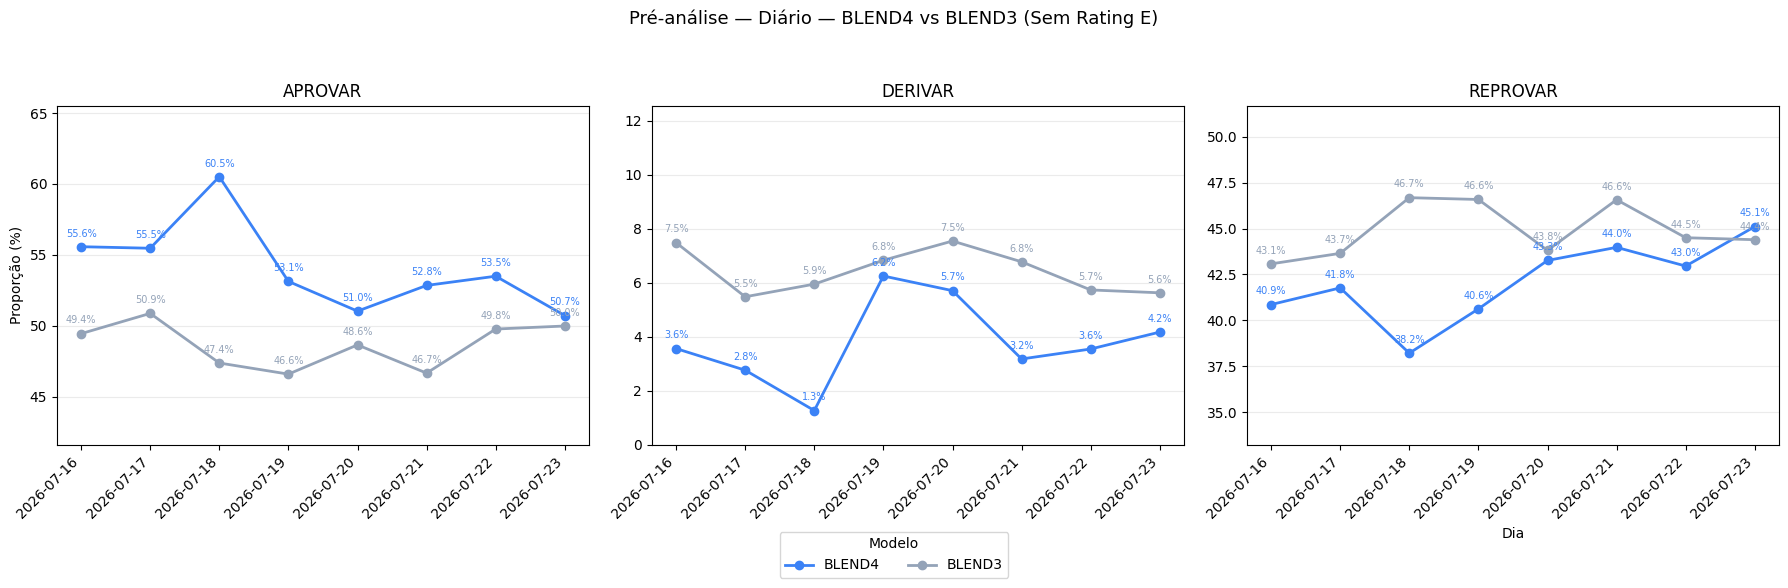

In [27]:
plot_pre_analysis_comparison(
    df_daily_wt_E,
    models=MODEL_ORDER_GRAPH,
    time_grain="day",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Pré-análise — Diário — BLEND4 vs BLEND3 (Sem Rating E)",
    # ylim=(0, 100),
)

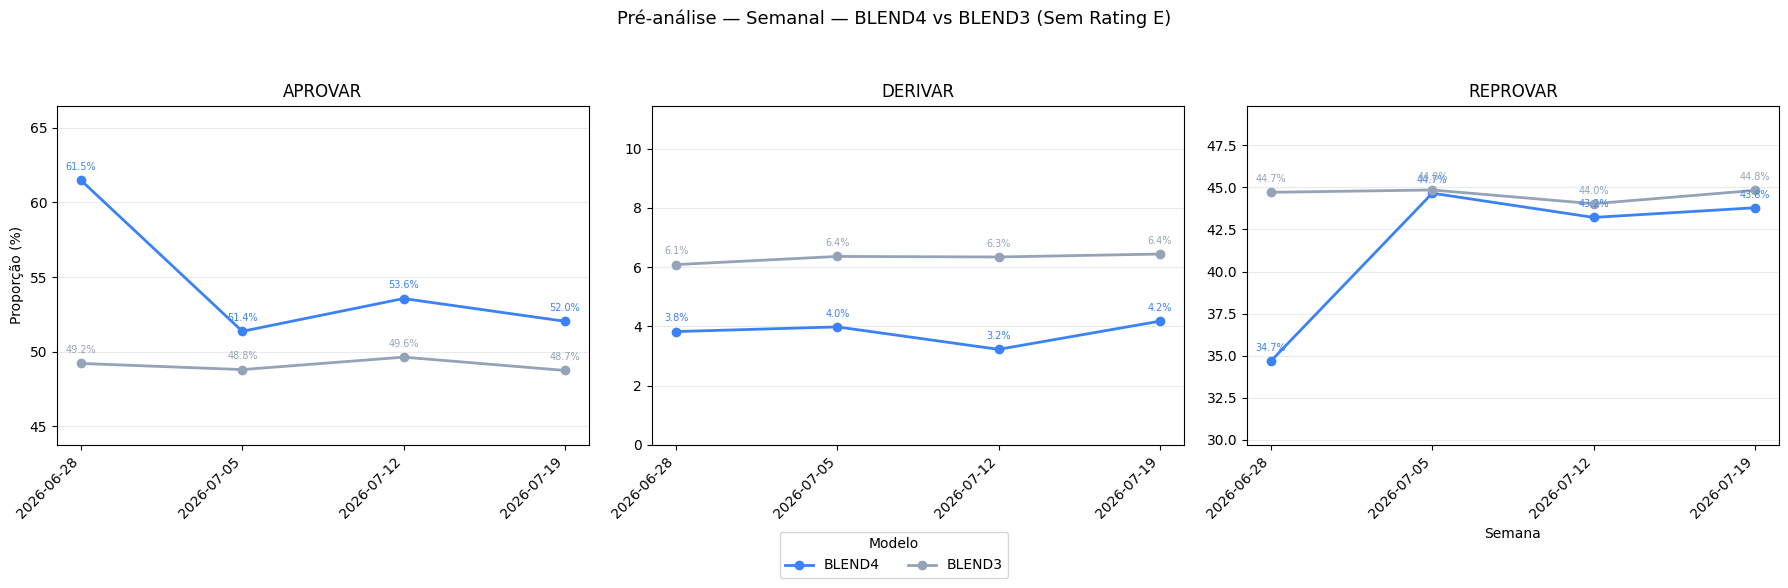

In [28]:
plot_pre_analysis_comparison(
    df_weekly_wt_E,
    models=MODEL_ORDER_GRAPH,
    time_grain="week",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Pré-análise — Semanal — BLEND4 vs BLEND3 (Sem Rating E)",
    # ylim=(0, 100),
)

## Funil
Comparação entre Blend3 e Blend4 em relação a Elegbilidade, Envio, Atiavação e Conversão.

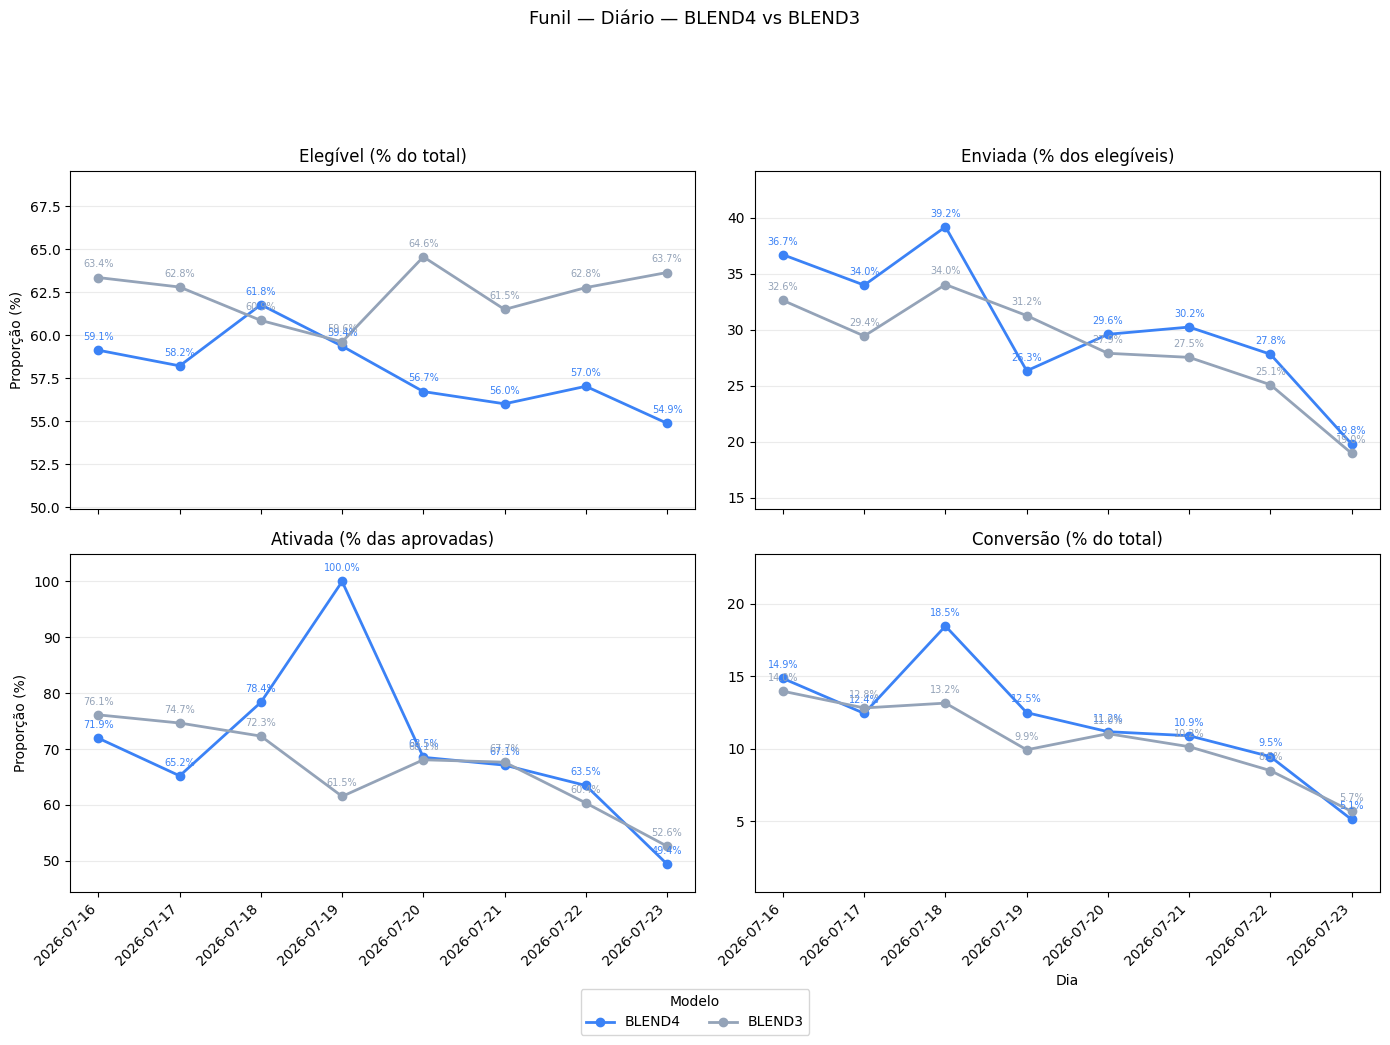

In [29]:
plot_funnel_metric_comparison(
    df_daily,
    models=MODEL_ORDER_GRAPH,
    metrics=FUNNEL_COMPARE_METRICS,
    time_grain="day",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Funil — Diário — BLEND4 vs BLEND3",
)

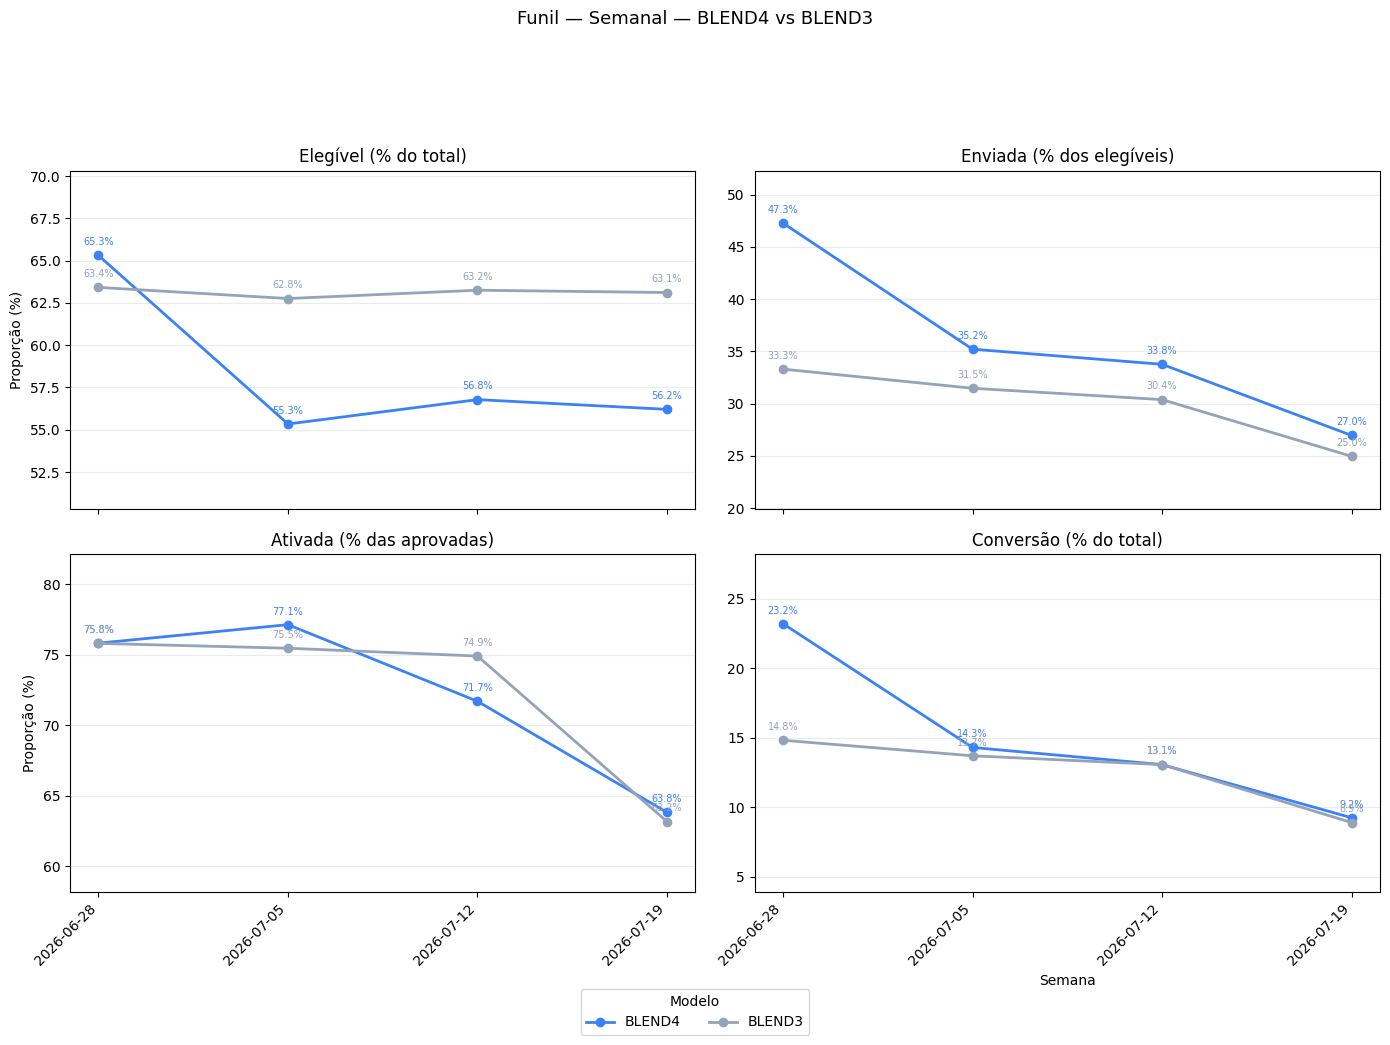

In [30]:
plot_funnel_metric_comparison(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    metrics=FUNNEL_COMPARE_METRICS,
    time_grain="week",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Funil — Semanal — BLEND4 vs BLEND3",
)

## Funil sem o Rating E do Blend3

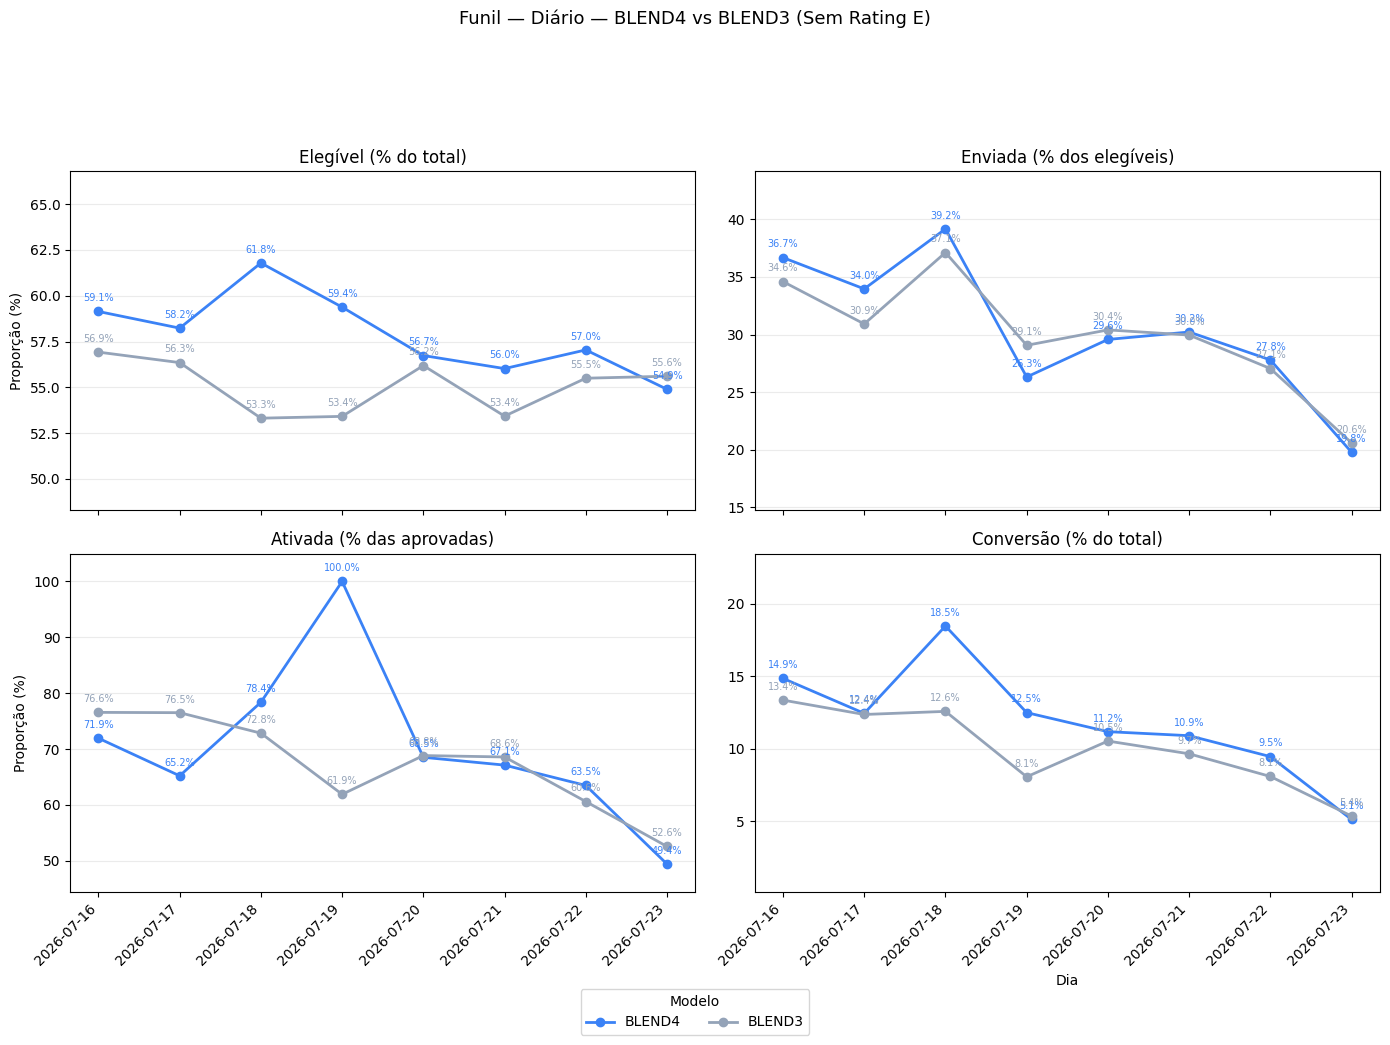

In [31]:
plot_funnel_metric_comparison(
    df_daily_wt_E,
    models=MODEL_ORDER_GRAPH,
    metrics=FUNNEL_COMPARE_METRICS,
    time_grain="day",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Funil — Diário — BLEND4 vs BLEND3 (Sem Rating E)",
)

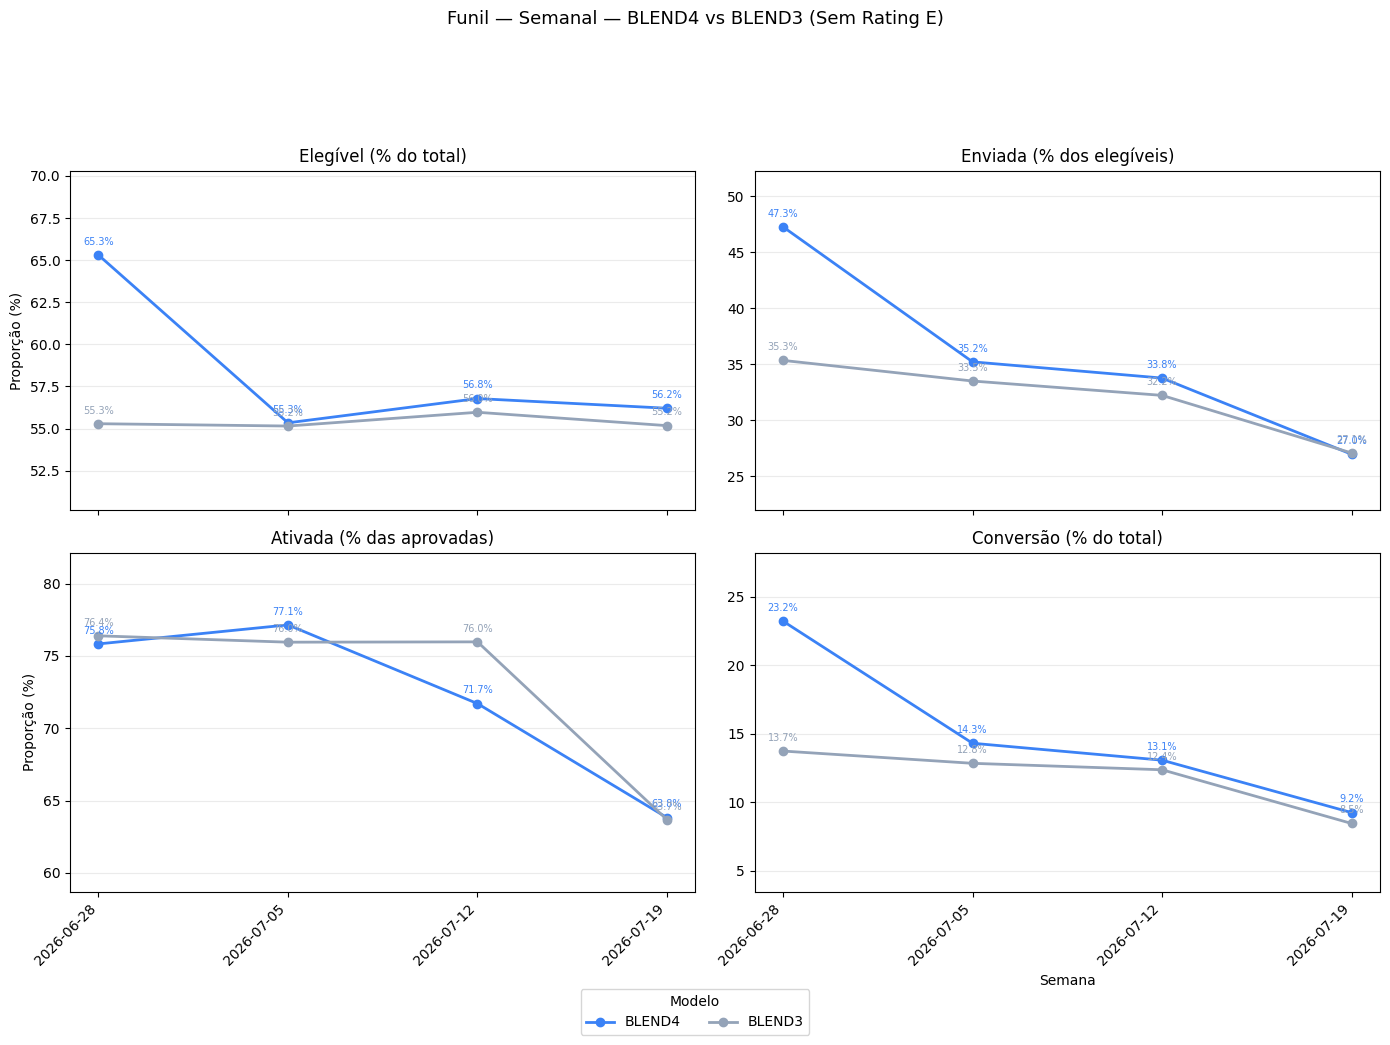

In [32]:
plot_funnel_metric_comparison(
    df_weekly_wt_E,
    models=MODEL_ORDER_GRAPH,
    metrics=FUNNEL_COMPARE_METRICS,
    time_grain="week",
    model_col=MODEL_COL,
    color_map=MODEL_COLOR_MAP,
    suptitle="Funil — Semanal — BLEND4 vs BLEND3 (Sem Rating E)",
)

## Tabela de Conversão
Tabela de Conversão com Mix, Elegibilidade, Envio, Ativação, Conversão e Diferença de Conversão entre os modelos Blend3 e Blend4 em números e em percentual.

In [33]:
tabela_counts = build_blend_comparison_summary_table_counts(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    model_col=MODEL_COL,
    time_grain="week",
)

def color_negative_diff_counts(row):
    val = row.get(("diff_conversao", ""))
    if pd.notna(val) and val < 0:
        return ["background-color: #f44336"] * len(row)
    return [""] * len(row)

display(
    tabela_counts.style
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])
    .format("{:,.0f}")  # inteiros com separador de milhar
    # .format("{:+.2f}%", subset=[("diff_conversao", "")])
    # .apply(color_negative_diff_counts, axis=1)
)

In [34]:
tabela_pct = build_blend_comparison_summary_table(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    model_col=MODEL_COL,
    time_grain="week",
    baseline_model="BLEND3",
    challenger_model="BLEND4",
)

def color_negative_diff_pct(row):
    val = row.get(("diff_conversao", ""))
    if pd.notna(val) and val < 0:
        return ["background-color: #f44336"] * len(row)
    return [""] * len(row)

pct_cols = [
    ("mix", "BLEND4"),
    ("%_elegivel", "BLEND4"),
    ("%_enviada_elegivel", "BLEND4"),
    ("%_ativada", "BLEND4"),
    ("%_conversao", "BLEND4"),
    ("mix", "BLEND3"),
    ("%_elegivel", "BLEND3"),
    ("%_enviada_elegivel", "BLEND3"),
    ("%_ativada", "BLEND3"),
    ("%_conversao", "BLEND3"),
]

display(
    tabela_pct.style
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])
    .format("{:.2%}", subset=pct_cols, na_rep="-")
    .format(
        lambda v: f"{v * 100:+.2f} pp" if pd.notna(v) else "-",
        subset=[("diff_conversao", "")],
    )
    .apply(color_negative_diff_pct, axis=1)
)

## Tabela de Conversão sem o Rating E
Tabela de Conversão com Mix, Elegibilidade, Envio, Ativação, Conversão e Diferença de Conversão entre os modelos Blend3 e Blend4 em números e em percentual, retirando o público com RATING E.

In [35]:
tabela_counts = build_blend_comparison_summary_table_counts(
    df_weekly_wt_E,
    models=MODEL_ORDER_GRAPH,
    model_col=MODEL_COL,
    time_grain="week",
)

def color_negative_diff_counts(row):
    val = row.get(("diff_conversao", ""))
    if pd.notna(val) and val < 0:
        return ["background-color: #f44336"] * len(row)
    return [""] * len(row)

display(
    tabela_counts.style
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])
    .format("{:,.0f}")  # inteiros com separador de milhar
    # .format("{:+.2f}%", subset=[("diff_conversao", "")])
    # .apply(color_negative_diff_counts, axis=1)
)

In [36]:
tabela_pct = build_blend_comparison_summary_table(
    df_weekly_wt_E,
    models=MODEL_ORDER_GRAPH,
    model_col=MODEL_COL,
    time_grain="week",
    baseline_model="BLEND3",
    challenger_model="BLEND4",
)

def color_negative_diff_pct(row):
    val = row.get(("diff_conversao", ""))
    if pd.notna(val) and val < 0:
        return ["background-color: #f44336"] * len(row)
    return [""] * len(row)

pct_cols = [
    ("mix", "BLEND4"),
    ("%_elegivel", "BLEND4"),
    ("%_enviada_elegivel", "BLEND4"),
    ("%_ativada", "BLEND4"),
    ("%_conversao", "BLEND4"),
    ("mix", "BLEND3"),
    ("%_elegivel", "BLEND3"),
    ("%_enviada_elegivel", "BLEND3"),
    ("%_ativada", "BLEND3"),
    ("%_conversao", "BLEND3"),
]

display(
    tabela_pct.style
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])
    .format("{:.2%}", subset=pct_cols, na_rep="-")
    .format(
        lambda v: f"{v * 100:+.2f} pp" if pd.notna(v) else "-",
        subset=[("diff_conversao", "")],
    )
    .apply(color_negative_diff_pct, axis=1)
)

## Conversão APROVADOS

In [37]:
weeks = sorted(
    prepare_week_columns(df_weekly.copy(), "requested_at")["year_week"]
    .drop_duplicates()
    .tolist()
)
print("Semanas:", weeks)

Semanas: ['2026-06-28', '2026-07-05', '2026-07-12', '2026-07-19']


In [38]:
for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df_weekly,
        models=["BLEND3", "BLEND4"],
        model_col=MODEL_COL,
        rating_col="rating_score_group",
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )
    display_blend_rating_decision_tables(
        counts, rates, week_label=week_label, title_prefix="Baseline"
    )

### Baseline — Semana 2026-06-28

**Leads (Counts)**

**Ativado / Lead (%)**

### Baseline — Semana 2026-07-05

**Leads (Counts)**

...

**Leads (Counts)**

**Ativado / Lead (%)**

### Baseline — Semana 2026-07-19

**Leads (Counts)**

**Ativado / Lead (%)**

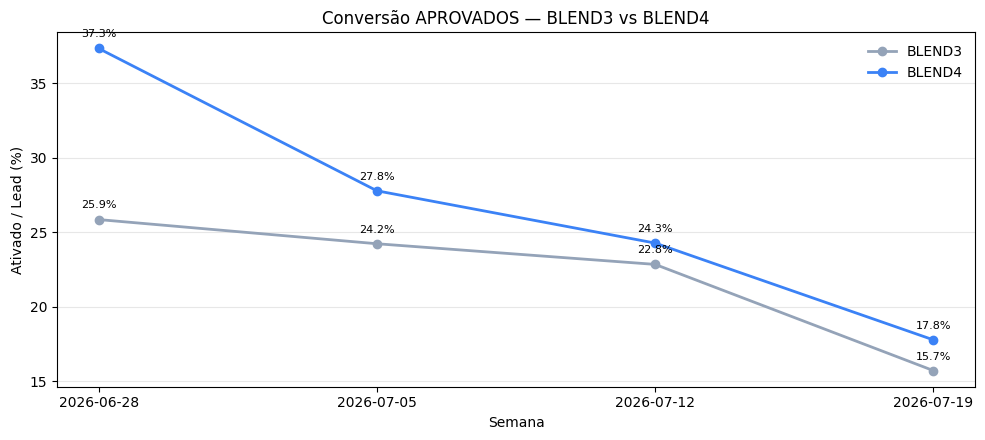

In [39]:
rows = []
for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df_weekly,
        models=["BLEND3", "BLEND4"],
        model_col=MODEL_COL,
        rating_col="rating_score_group",
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )
    for model in ["BLEND3", "BLEND4"]:
        leads = counts.loc["Total", (model, "APROVADO")]
        if leads == 0 or pd.isna(leads):
            pct = np.nan
        else:
            pct = rates.loc["Total", (model, "APROVADO")]
        rows.append({"week": week_label, "model": model, "ativados_pct": pct})

df_tot = pd.DataFrame(rows)
pivot = (
    df_tot.pivot(index="week", columns="model", values="ativados_pct")
    .reindex(columns=["BLEND3", "BLEND4"])
)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = range(len(pivot.index))
for model in ["BLEND3", "BLEND4"]:
    ax.plot(
        x,
        pivot[model],
        marker="o",
        linewidth=2,
        label=model,
        color=MODEL_COLOR_MAP.get(model),
    )
    for i, v in enumerate(pivot[model]):
        if pd.notna(v):
            ax.annotate(
                f"{v:.1f}%",
                (i, v),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=8,
            )

ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index)
ax.set_ylabel("Ativado / Lead (%)")
ax.set_xlabel("Semana")
ax.set_title("Conversão APROVADOS — BLEND3 vs BLEND4")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Conversão APROVADOS sem Rating E

In [40]:
for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df_weekly_wt_E,
        models=["BLEND3", "BLEND4"],
        model_col=MODEL_COL,
        rating_col="rating_score_group",
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )
    display_blend_rating_decision_tables(
        counts, rates, week_label=week_label, title_prefix="Sem Rating E (Blend3)"
    )

### Sem Rating E (Blend3) — Semana 2026-06-28

**Leads (Counts)**

**Ativado / Lead (%)**

### Sem Rating E (Blend3) — Semana 2026-07-05

**Leads (Counts)**

...

**Leads (Counts)**

**Ativado / Lead (%)**

### Sem Rating E (Blend3) — Semana 2026-07-19

**Leads (Counts)**

**Ativado / Lead (%)**

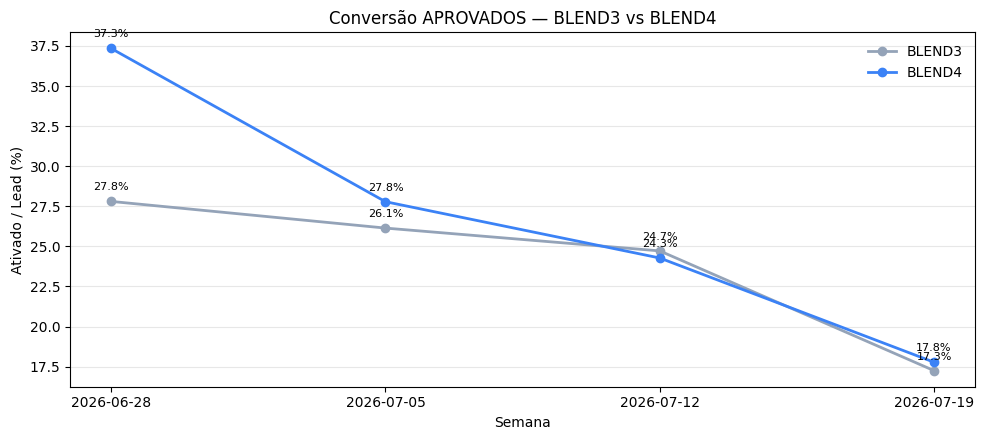

In [41]:
rows = []
for week in weeks:
    counts, rates, week_label = build_blend_rating_decision_tables(
        df_weekly_wt_E,
        models=["BLEND3", "BLEND4"],
        model_col=MODEL_COL,
        rating_col="rating_score_group",
        rating_order=RATING_ORDER,
        decision_order=PRE_ANALISE_ORDER,
        week=week,
    )
    for model in ["BLEND3", "BLEND4"]:
        leads = counts.loc["Total", (model, "APROVADO")]
        if leads == 0 or pd.isna(leads):
            pct = np.nan
        else:
            pct = rates.loc["Total", (model, "APROVADO")]
        rows.append({"week": week_label, "model": model, "ativados_pct": pct})

df_tot = pd.DataFrame(rows)
pivot = (
    df_tot.pivot(index="week", columns="model", values="ativados_pct")
    .reindex(columns=["BLEND3", "BLEND4"])
)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = range(len(pivot.index))
for model in ["BLEND3", "BLEND4"]:
    ax.plot(
        x,
        pivot[model],
        marker="o",
        linewidth=2,
        label=model,
        color=MODEL_COLOR_MAP.get(model),
    )
    for i, v in enumerate(pivot[model]):
        if pd.notna(v):
            ax.annotate(
                f"{v:.1f}%",
                (i, v),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=8,
            )

ax.set_xticks(list(x))
ax.set_xticklabels(pivot.index)
ax.set_ylabel("Ativado / Lead (%)")
ax.set_xlabel("Semana")
ax.set_title("Conversão APROVADOS — BLEND3 vs BLEND4")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Mix de Rating por Modelo: Blend 4 vs. Blend3
Mix de Rating por Modelo, considerando os 5 Rating's comparáveis.

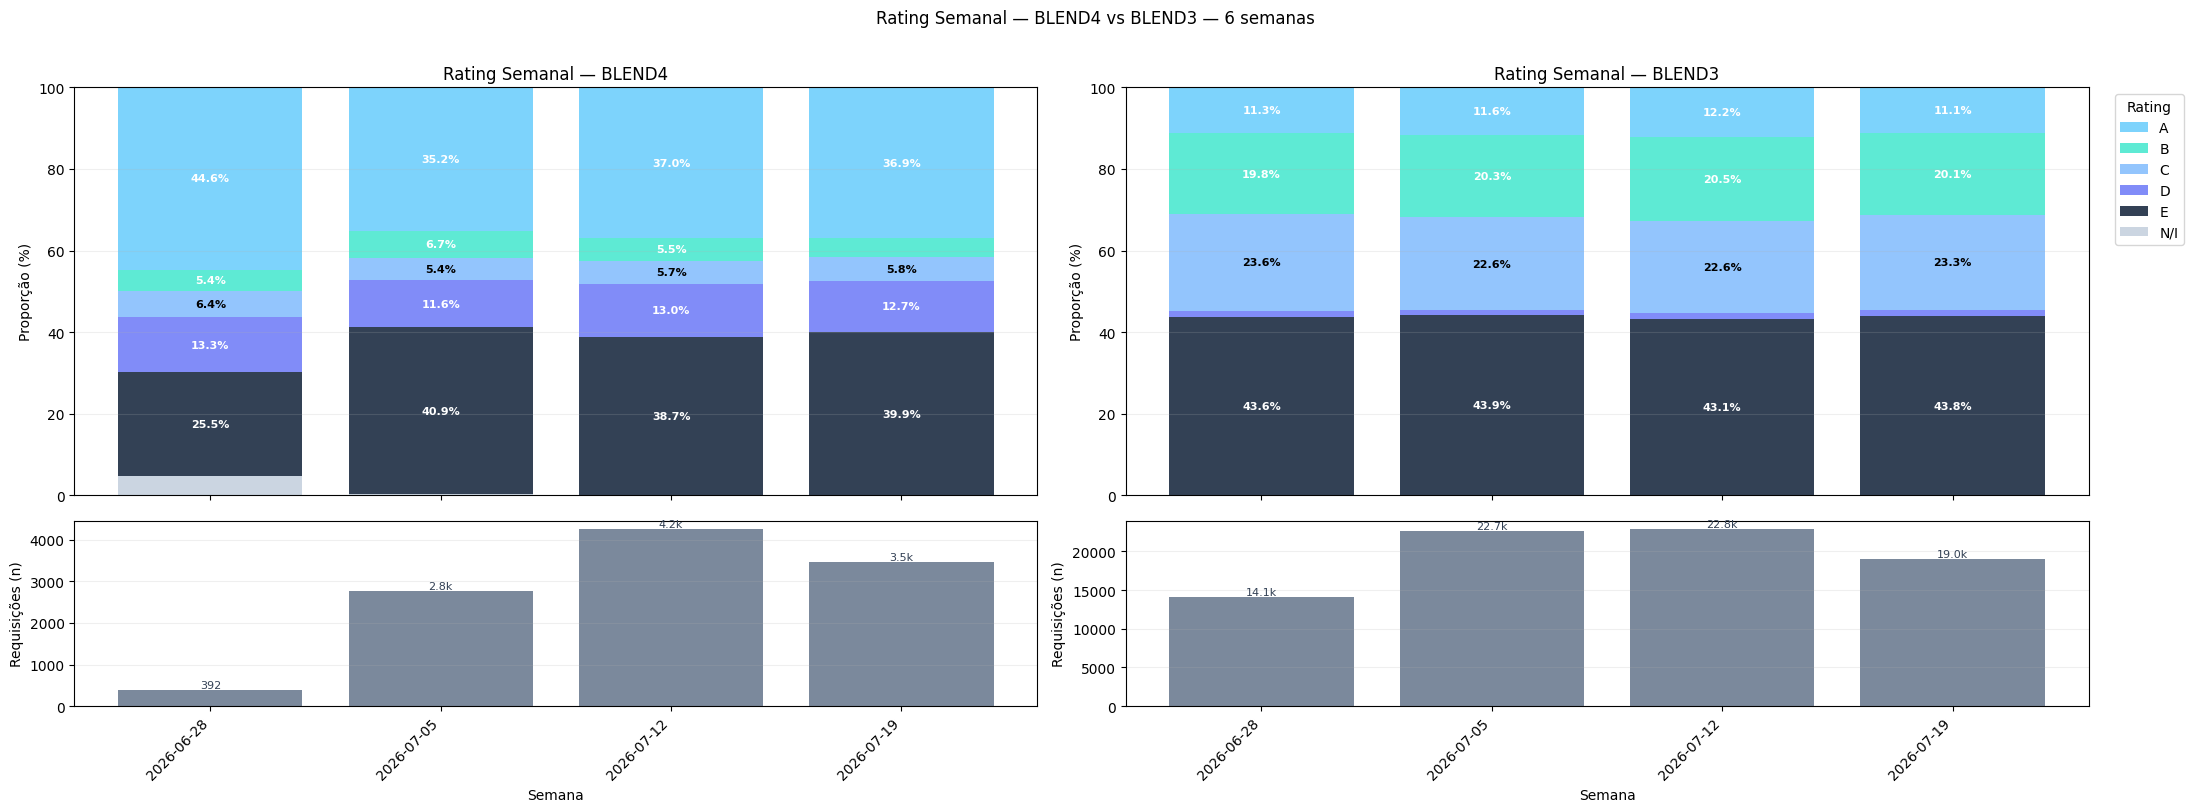

In [42]:
models_data = []
for model in MODEL_ORDER_GRAPH:
    df_model = df_weekly[df_weekly[MODEL_COL] == model]
    if df_model.empty:
        continue

    pct_df, _, volume = compute_category_mix(
        df_model,
        category_col="rating_score_group",
        time_grain="week",
    )
    models_data.append((model, pct_df, volume))

if not models_data:
    print("[skip] Sem dados para rating diário comparável")
else:
    all_periods = sorted(set().union(*[pct.index for _, pct, _ in models_data]))
    aligned = [
        (
            model,
            pct_df.reindex(all_periods, fill_value=0),
            volume.reindex(all_periods, fill_value=0),
        )
        for model, pct_df, volume in models_data
    ]

    n = len(aligned)
    fig, axes = plt.subplots(
        2, n,
        figsize=(11 * n, 8),
        sharex="col",
        gridspec_kw={"height_ratios": [2.2, 1]},
    )
    if n == 1:
        axes = axes.reshape(2, 1)

    for col, (model, pct_df, volume) in enumerate(aligned):
        _draw_rating_mix_panel(
            axes[0, col],
            axes[1, col],
            pct_df,
            volume,
            panel_title=f"Rating Semanal — {model}",
            xlabel="Semana",
            category_order=RATING_ORDER,
            color_map=RATING_COLOR_MAP,
            text_color_map=RATING_TEXT_COLOR_MAP,
            reverse_stack=True,
            min_label_pct=5.0,
            show_legend=(col == n - 1),  # legenda só no painel da direita
            legend_title="Rating",
        )

    fig.suptitle(
        f"Rating Semanal — BLEND4 vs BLEND3 — {WINDOW_WEEKS} semanas",
        y=1.01,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

## Mix de Rating Política - Esperado vs. Produção
Mix de Rating de acordo com  o Classe Política, ou seja, com maior detalhamento de Rating (A+ e B+, por exemplo). 
Nesse caso, comparamos com o que era esperado no desenvolvimento do Modelo Blend4.
Temos a tabela com o Mix de Rating ao longo do Desenvolvimento e OOT e o gráfico que compara o último mês da OOT (2025-08) com os resultados em Produção.

In [43]:
RATING_CL_POL_COL = "rating_score_ds"

RATING_CL_POL_ORDER = [
    "1.A+",
    "2.A",
    "3.B+",
    "4.B",
    "5.C",
    "6.D+",
    "7.D",
    "8.E",
    "9.E-BVS",
    "N/I"
]

RATING_CL_POL_COLOR_MAP = {
    "1.A+":   "#22D3EE",  # best
    "2.A":    "#38BDF8",
    "3.B+":   "#2DD4BF",
    "4.B":    "#6EE7B7",
    "5.C":    "#93C5FD",
    "6.D+":   "#A5B4FC",
    "7.D":    "#818CF8",
    "8.E":    "#475569",
    "9.E-BVS": "#1E293B",
    "N/I":    "#4f6d9e",
}

RATING_CL_POL_TEXT_COLOR_MAP = {
    "1.A+":    "black",
    "2.A":     "black",
    "3.B+":    "black",
    "4.B":     "black",
    "5.C":     "black",
    "6.D+":    "white",
    "7.D":     "white",
    "8.E":     "white",
    "9.E-BVS": "white",
    "N/I":    "white",
}

In [44]:
df_rt_dev = pd.read_csv(ANALYTICS_DIR/"dev_rating_pol_blend4.csv").rename(columns={"9.E.BVS": "9.E-BVS"})
df_rt_dev = df_rt_dev[df_rt_dev["safra"] == "2025-08"]
df_rt_dev

,safra,1.A+,2.A,3.B+,4.B,5.C,6.D+,7.D,8.E,9.E-BVS,volume
11,2025-08,5.479852,11.252605,11.238394,11.356029,5.729331,5.888019,12.401314,26.162919,10.491537,126664


In [45]:
model = "BLEND4"
safra_ref = "2025-08"
min_label_pct = 1.0

# --- Esquerda: proporções esperadas (dev) ---
row = df_rt_dev.loc[df_rt_dev["safra"] == safra_ref]
if row.empty:
    raise ValueError(f"Safra {safra_ref} não encontrada em df_rt_dev")

pct_expected = row.set_index("safra").reindex(columns=RATING_CL_POL_ORDER, fill_value=0)
vol_expected = row.set_index("safra")["volume"]

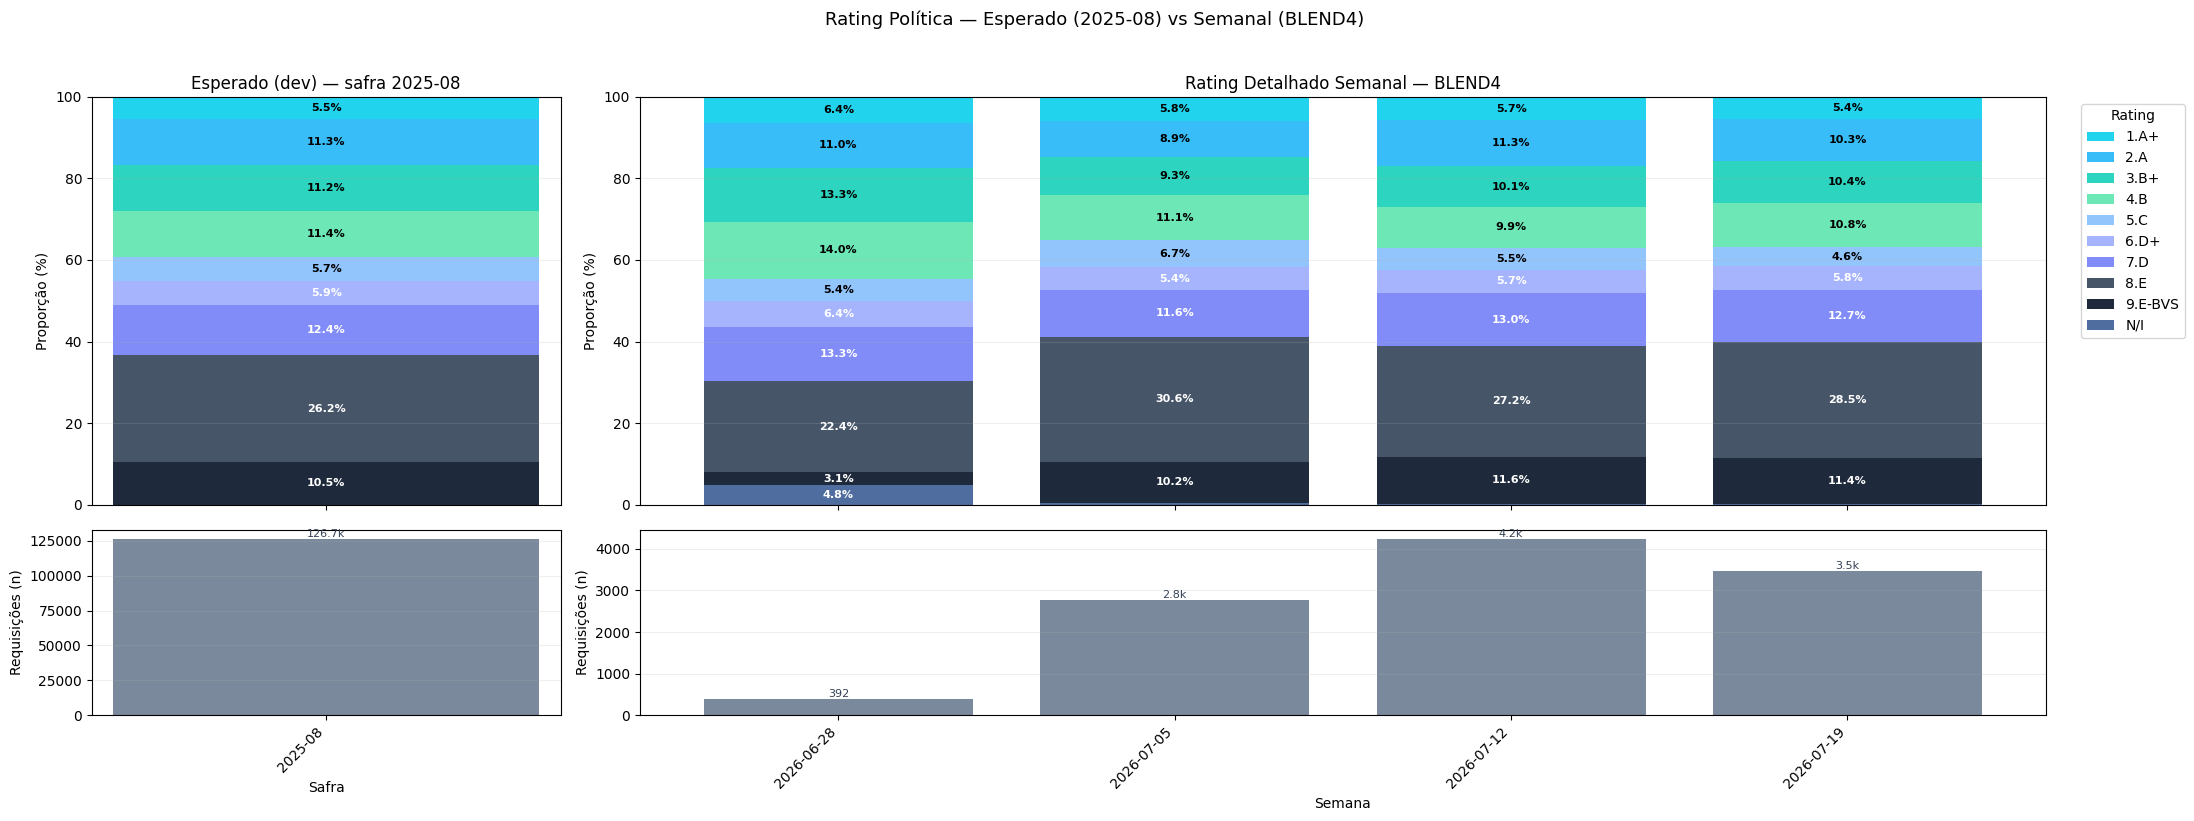

In [46]:
df_model = df_weekly[df_weekly["bureau_nm_ajust"] == model]

pct_prod, _, vol_prod = compute_category_mix(
    df_model,
    category_col=RATING_CL_POL_COL,
    time_grain="week",
)

if pct_prod.empty:
    print(f"[skip] Sem dados semanais para: {model}")
else:
    fig, axes = plt.subplots(
        2, 2,
        figsize=(22, 8),
        sharex="col",
        gridspec_kw={
            "height_ratios": [2.2, 1],
            "width_ratios": [1, 3],  # mais espaço para as semanas à direita
        },
    )

    _draw_rating_mix_panel(
        axes[0, 0], axes[1, 0],
        pct_expected,
        vol_expected,
        panel_title=f"Esperado (dev) — safra {safra_ref}",
        xlabel="Safra",
        category_order=RATING_CL_POL_ORDER,
        color_map=RATING_CL_POL_COLOR_MAP,
        text_color_map=RATING_CL_POL_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=min_label_pct,
        show_legend=False,
        legend_title="Rating",
    )

    _draw_rating_mix_panel(
        axes[0, 1], axes[1, 1],
        pct_prod,
        vol_prod,
        panel_title=f"Rating Detalhado Semanal — {model}",
        xlabel="Semana",
        category_order=RATING_CL_POL_ORDER,
        color_map=RATING_CL_POL_COLOR_MAP,
        text_color_map=RATING_CL_POL_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=min_label_pct,
        show_legend=True,
        legend_title="Rating",
    )

    fig.suptitle(
        f"Rating Política — Esperado ({safra_ref}) vs Semanal ({model})",
        y=1.02,
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()

## Funil por Rating

Funil de Elegibilidade, Envio e Conversão comparado por Rating (A, B, C, D e E) em cada um dos Modelos: Blend3 e Blend4.

In [47]:
RATING_COL = "rating_score_group"

In [48]:
MIN_VOLUME_WEEKLY = 100
RATINGS_TO_PLOT = ["A", "B", "C", "D", "E", "N/I"]

MODEL_LABELS = {
    "BLEND3": "Blend 3",
    "BLEND4": "Blend 4",
}

METRICS = {
    "elegivel_pct_total": "Elegível (%)",
    "enviada_pct_elegivel": "Envio (%)",
    "conversao_pct_total": "Conversão (%)",
}

funnel_long = build_funnel_by_rating_table(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    min_volume_per_model=MIN_VOLUME_WEEKLY,
)

for metric_col, metric_label in METRICS.items():
    print(f"\n=== {metric_label} — Semanal — por rating ===")

    tabela = funnel_long.pivot_table(
        index="period",
        columns=["model", "rating"],
        values=metric_col,
        aggfunc="first",
    ).sort_index()

    # Renomeia colunas para ficar legível
    tabela.columns = pd.MultiIndex.from_tuples([
        (MODEL_LABELS.get(model, model), f"Rating {rating}")
        for model, rating in tabela.columns
    ])

    display(
        tabela.style
        .format("{:.1f}", na_rep="—")
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "center")]},
        ])
    )


=== Elegível (%) — Semanal — por rating ===



=== Envio (%) — Semanal — por rating ===



=== Conversão (%) — Semanal — por rating ===


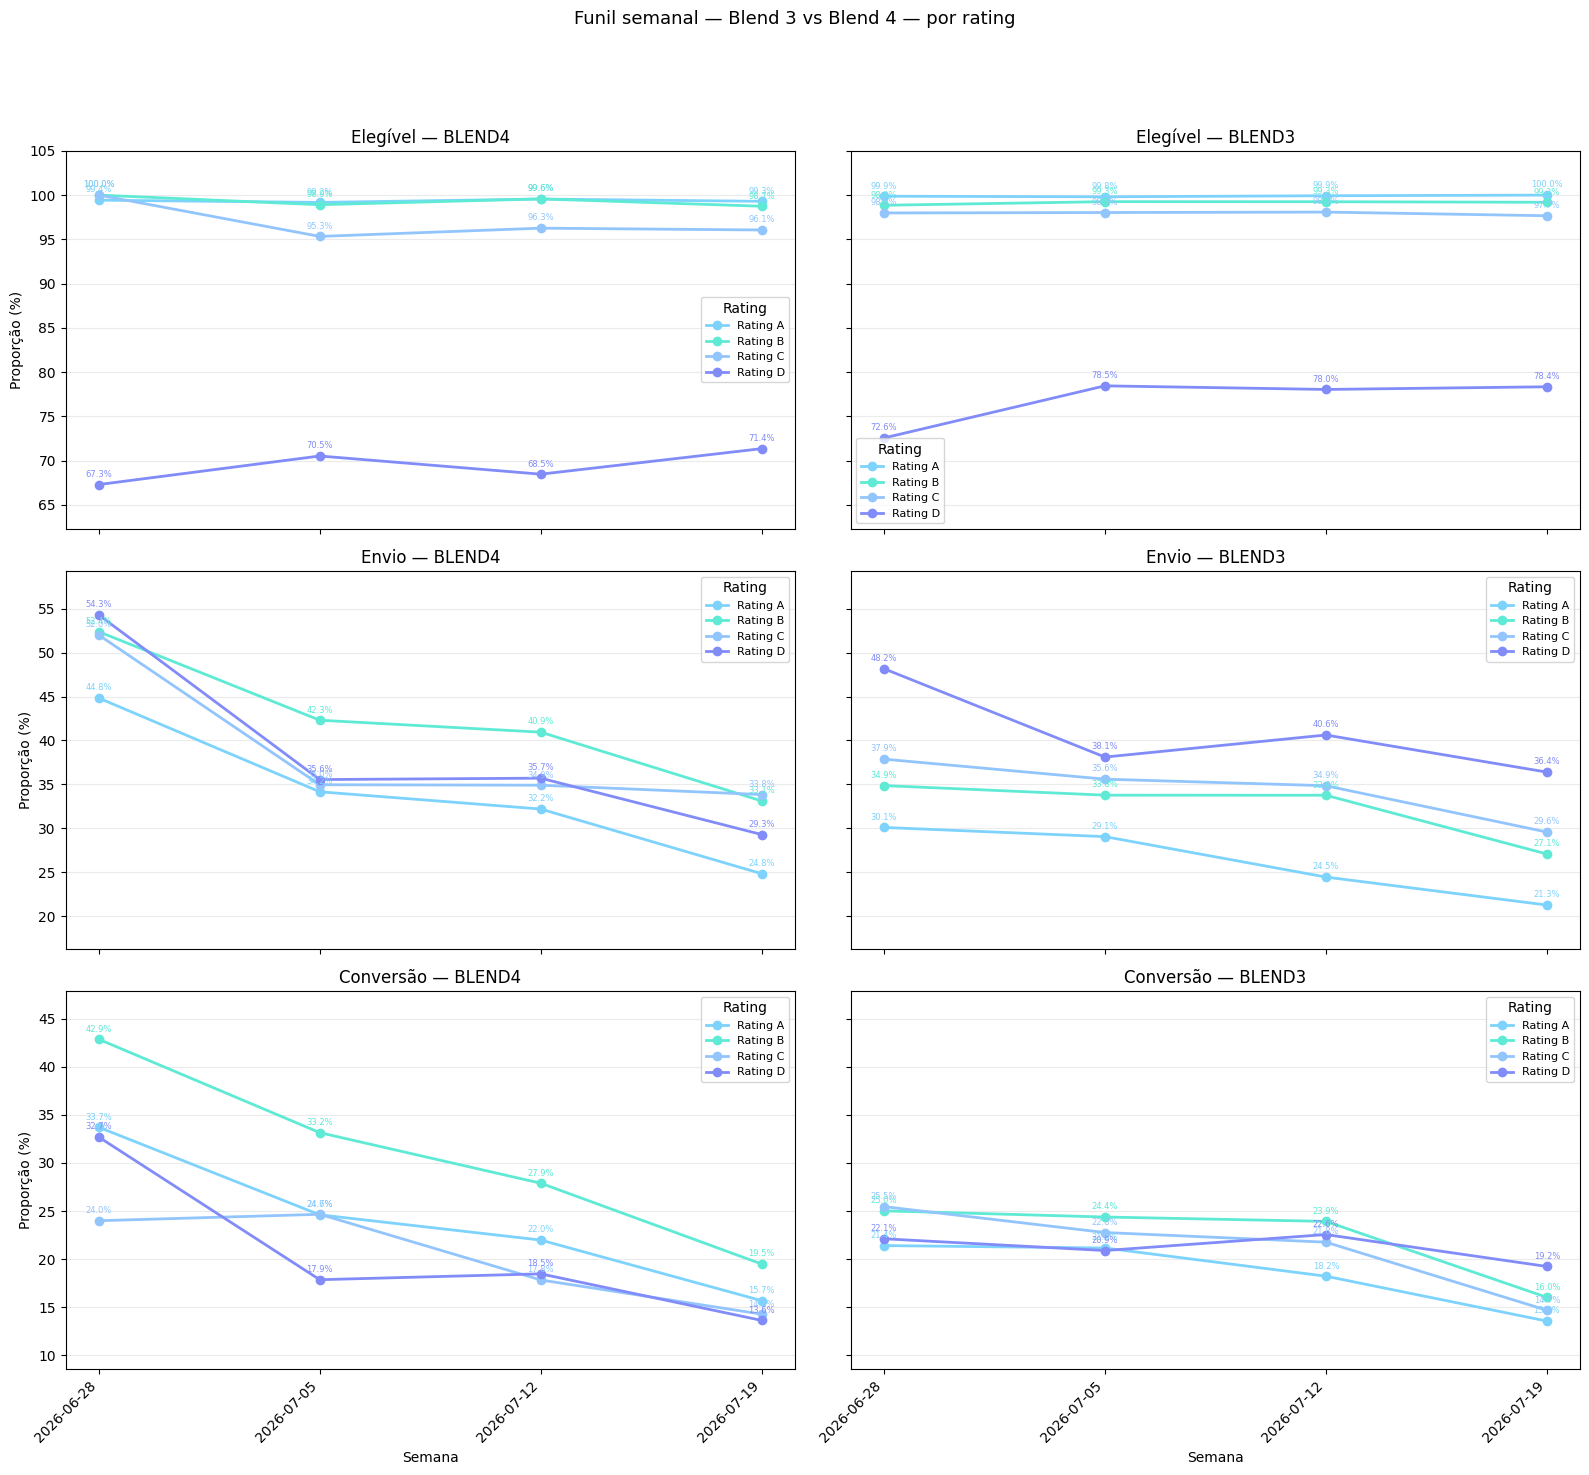

In [49]:

RATINGS_TO_PLOT = ["A", "B", "C", "D"]
plot_funnel_metrics_by_rating_side_by_side(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    # min_volume_per_model=MIN_VOLUME_WEEKLY,
    ylim=None,              # auto por linha
    auto_ylim_pad=5.0,      # margem acima/abaixo dos dados
    show_labels=True,
    suptitle="Funil semanal — Blend 3 vs Blend 4 — por rating",
)

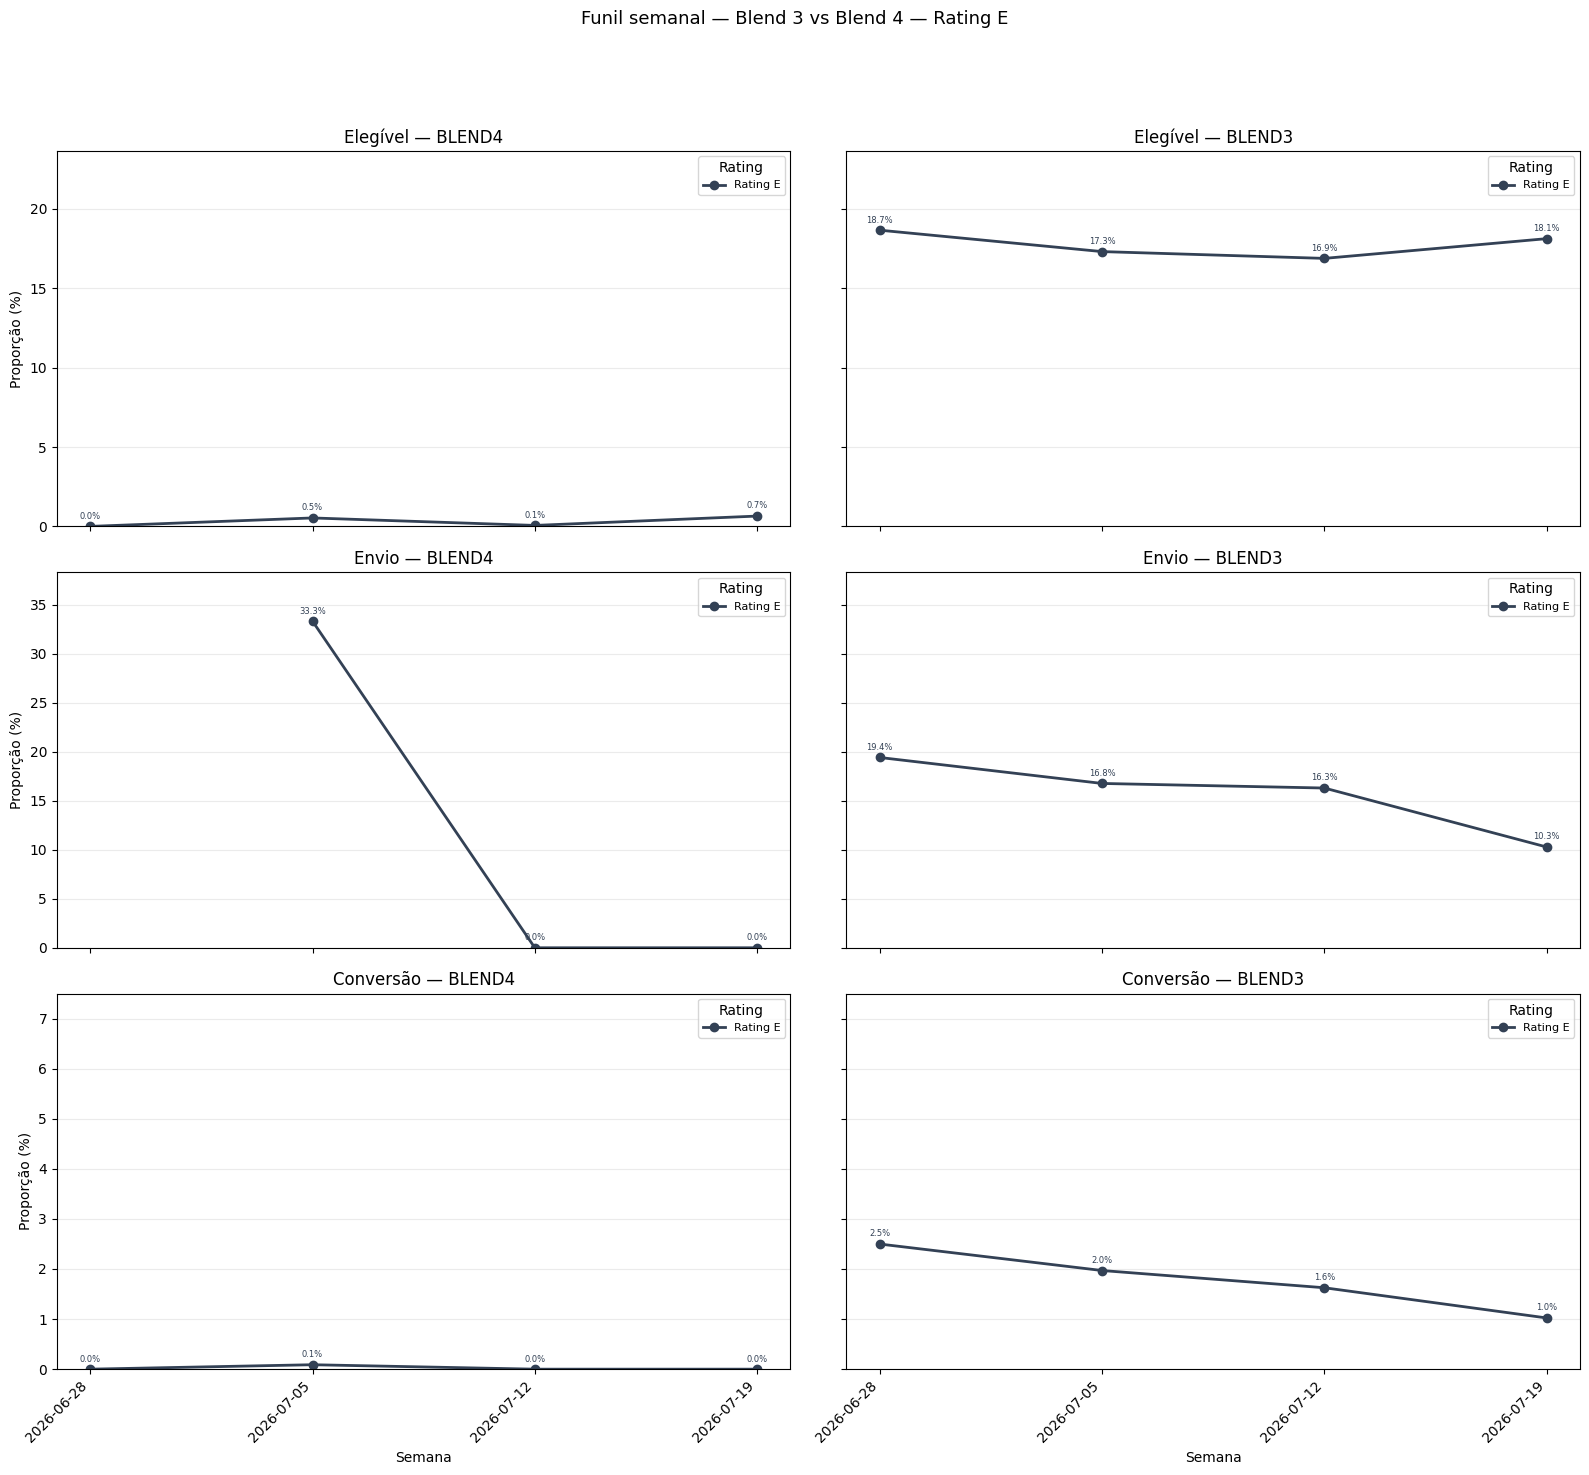

In [50]:

RATINGS_TO_PLOT = ["E"]
plot_funnel_metrics_by_rating_side_by_side(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    # min_volume_per_model=MIN_VOLUME_WEEKLY,
    ylim=None,              # auto por linha
    auto_ylim_pad=5.0,      # margem acima/abaixo dos dados
    show_labels=True,
    suptitle="Funil semanal — Blend 3 vs Blend 4 — Rating E",
)

## Pré-Análise por Rating

Pré Análise (Aprovar, Derivar e Reprovar) aberto por Rating (A, B, C, D e E) e comparando os Modelos Blend3 e Blend4.

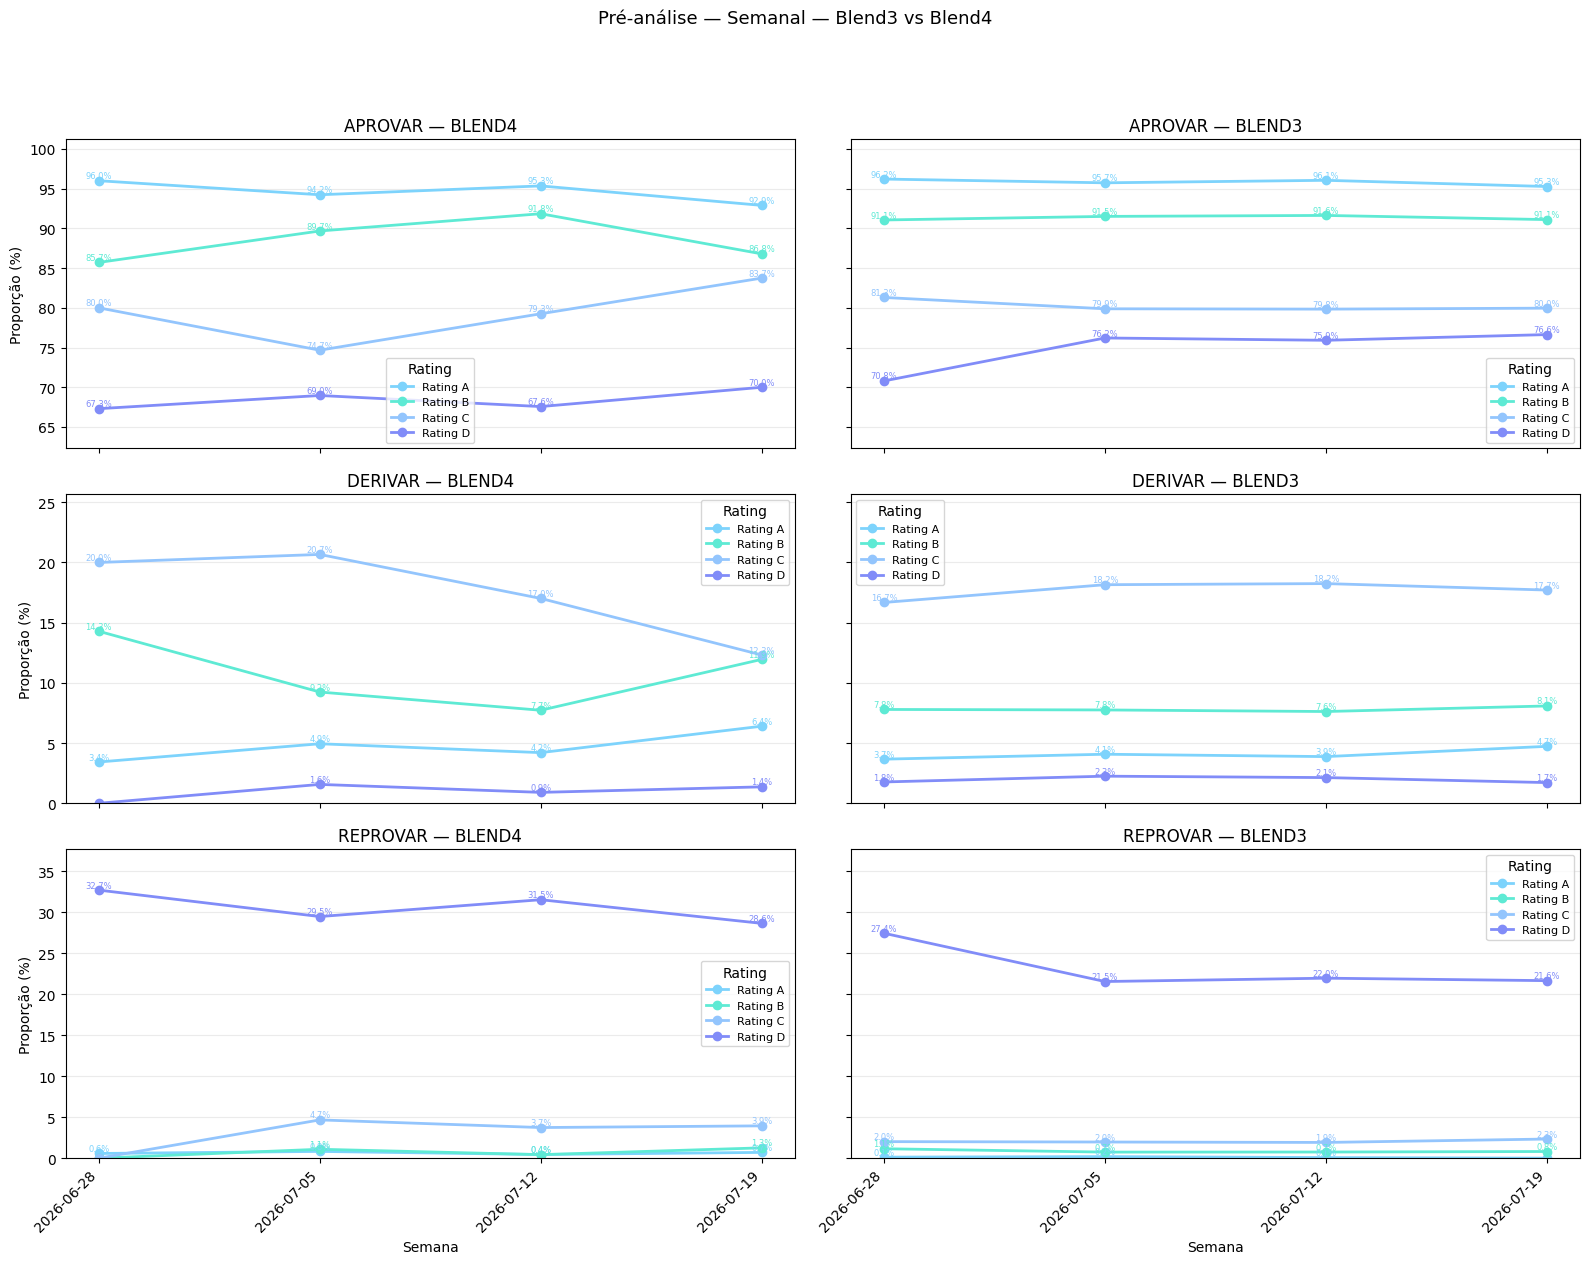

In [51]:
MIN_VOLUME_WEEKLY = 100
RATINGS_TO_PLOT = ["A", "B", "C", "D"]  # sem N/I, se preferir

plot_pre_analysis_by_rating_side_by_side(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    rating_color_map=RATING_COLOR_MAP,
    # min_volume_per_model=MIN_VOLUME_WEEKLY,
    # ylim=None  ← padrão: auto por linha
    suptitle="Pré-análise — Semanal — Blend3 vs Blend4",
)

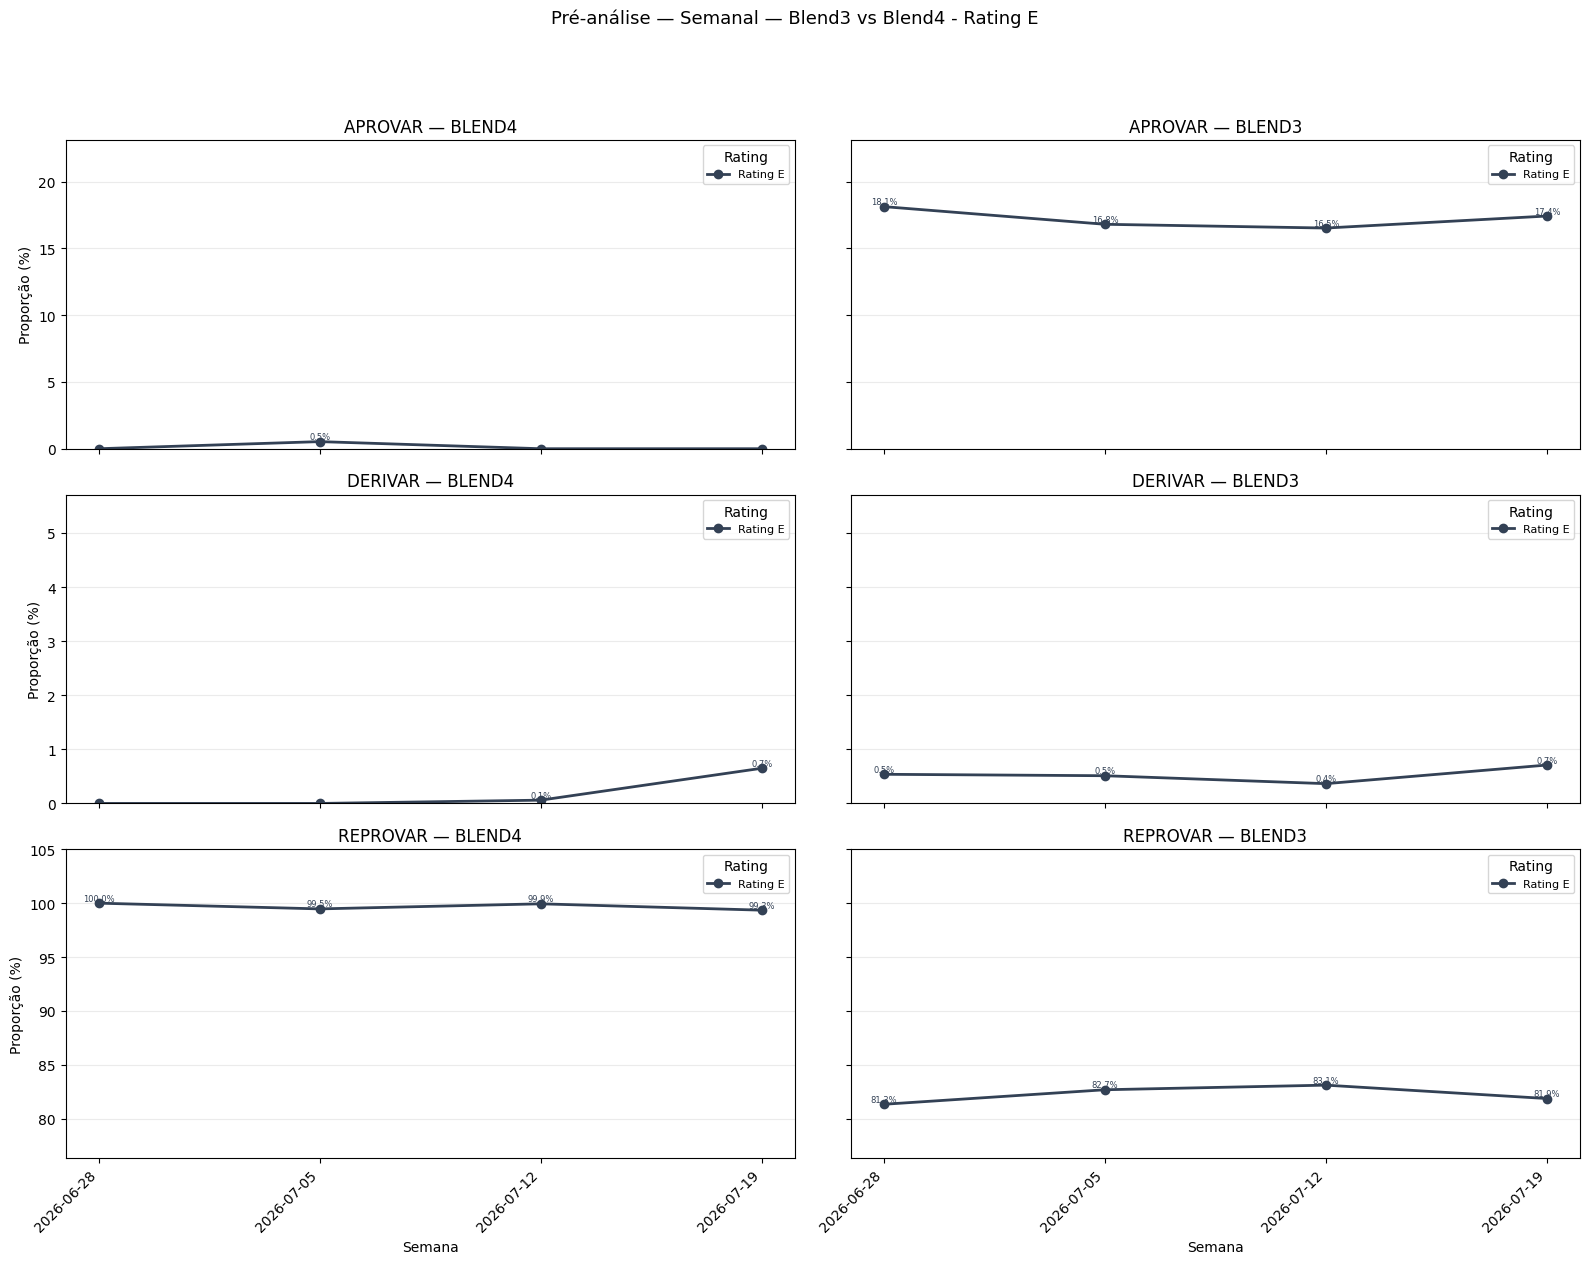

In [52]:
MIN_VOLUME_WEEKLY = 100
RATINGS_TO_PLOT = ["E"]  # sem N/I, se preferir

plot_pre_analysis_by_rating_side_by_side(
    df_weekly,
    models=MODEL_ORDER_GRAPH,
    ratings=RATINGS_TO_PLOT,
    time_grain="week",
    model_col=MODEL_COL,
    rating_col=RATING_COL,
    rating_color_map=RATING_COLOR_MAP,
    # min_volume_per_model=MIN_VOLUME_WEEKLY,
    # ylim=None  ← padrão: auto por linha
    suptitle="Pré-análise — Semanal — Blend3 vs Blend4 - Rating E",
)

## Salvar HTML

In [53]:
import importlib

import build_report_html

importlib.reload(build_report_html)

REPORTS_DIR = Path("Monitores")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

report_path = build_report_html.export_notebook_report(
    title="Monitoramento Funil Blend4",
    output_path=REPORTS_DIR / "02.Monitoramento_Funil_Blend4_report.html",
)
print(f"Report generated: {report_path}")


Report updated: /Users/lucas.nascimento/Monitoramento_Modelos/Monitores/02.Monitoramento_Funil_Blend4_report.html (2.89 MB) | generated at 2026-07-24 11:08:28 -03
If the browser still shows old content, hard-refresh (Cmd+Shift+R).
Report generated: /Users/lucas.nascimento/Monitoramento_Modelos/Monitores/02.Monitoramento_Funil_Blend4_report.html
